In [1]:
#import required libraries

import pandas as pd
import numpy as np
import time
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

from sklearn.metrics import (classification_report, f1_score, accuracy_score, confusion_matrix)

import seaborn as sbn
import matplotlib.pyplot as plt

#import pytorch since tensorflow is not supporting in python 3.14
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, ClassifierMixin

torch.manual_seed(42)

import shap

print("All libraries imported")

All libraries imported


In [2]:
#configuration of paths of preprocessed train and test sets

CICIoT_Train= r"C:\Users\NARASIMHA N\Documents\comparative_analysis_arp_spoofing\Kitsune Feature Extraction\Dataset Preprocessing\CICIoT2023 Dataset\Test and Train Sets\CICIoT2023_train.csv"
CICIoT_Test= r"C:\Users\NARASIMHA N\Documents\comparative_analysis_arp_spoofing\Kitsune Feature Extraction\Dataset Preprocessing\CICIoT2023 Dataset\Test and Train Sets\CICIoT2023_test.csv"

IoT_NID_Train= r"C:\Users\NARASIMHA N\Documents\comparative_analysis_arp_spoofing\Kitsune Feature Extraction\Dataset Preprocessing\IoT Network Intrusion Dataset\Testing and Training\IoT_NID_train.csv"
IoT_NID_Test= r"C:\Users\NARASIMHA N\Documents\comparative_analysis_arp_spoofing\Kitsune Feature Extraction\Dataset Preprocessing\IoT Network Intrusion Dataset\Testing and Training\IoT_NID_test.csv"

UQIoT_Train= r"C:\Users\NARASIMHA N\Documents\comparative_analysis_arp_spoofing\Kitsune Feature Extraction\Dataset Preprocessing\UQ-IoT Dataset\Testing and Training CSVs\UQ-IoT_train.csv"
UQIoT_Test= r"C:\Users\NARASIMHA N\Documents\comparative_analysis_arp_spoofing\Kitsune Feature Extraction\Dataset Preprocessing\UQ-IoT Dataset\Testing and Training CSVs\UQ-IoT_test.csv"

mininet_Train=r"C:\Users\NARASIMHA N\Documents\comparative_analysis_arp_spoofing\Kitsune Feature Extraction\Dataset Preprocessing\MininetDatasetEvaluation\Testing and Training CSVs\mininet_train.csv"
mininet_Test=r"C:\Users\NARASIMHA N\Documents\comparative_analysis_arp_spoofing\Kitsune Feature Extraction\Dataset Preprocessing\MininetDatasetEvaluation\Testing and Training CSVs\mininet_test.csv"

Output_Dir= r"C:\Users\NARASIMHA N\Documents\comparative_analysis_arp_spoofing\Kitsune Feature Extraction\Dataset Preprocessing\Cross-Dataset Evaluation\Outputs"

Label_columns= "label"

os.makedirs(Output_Dir, exist_ok=True)
print("All paths are assigned.")

All paths are assigned.


In [3]:
#loading all test antrain CSVs into dataframes

ciciot_train=pd.read_csv(CICIoT_Train)
ciciot_test=pd.read_csv(CICIoT_Test)

iot_nid_train=pd.read_csv(IoT_NID_Train)
iot_nid_test=pd.read_csv(IoT_NID_Test)

uqiot_train=pd.read_csv(UQIoT_Train)
uqiot_test=pd.read_csv(UQIoT_Test)

mininet_train=pd.read_csv(mininet_Train)
mininet_test=pd.read_csv(mininet_Test)

print("Loaded shapes: \n")
print(f"CICIoT2023 Dataset --> Train: {ciciot_train.shape}, Test: {ciciot_test.shape}")
print(f"IoT_NID Dataset    --> Train: {iot_nid_train.shape}, Test: {iot_nid_test.shape}")
print(f"UQIoT Dataset      --> Train: {uqiot_train.shape}, Test: {uqiot_test.shape}")
print(f"Mininet Dataset      --> Train: {mininet_train.shape}, Test: {mininet_test.shape}")

Loaded shapes: 

CICIoT2023 Dataset --> Train: (32000, 103), Test: (8000, 103)
IoT_NID Dataset    --> Train: (32000, 103), Test: (8000, 103)
UQIoT Dataset      --> Train: (24482, 103), Test: (7061, 103)
Mininet Dataset      --> Train: (32000, 103), Test: (8000, 103)


In [4]:
#confomation of all datasets contains same set of features

ciciot_features= [feature for feature in ciciot_train.columns if feature != Label_columns]
iot_nid_features= [feature for feature in iot_nid_train.columns if feature != Label_columns]
uqiot_features= [feature for feature in uqiot_train.columns if feature != Label_columns]
mininet_features= [feature for feature in mininet_train.columns if feature != Label_columns] 

match= (ciciot_features==iot_nid_features==uqiot_features==mininet_features)
if(match):
    print("All datasets contain same set of features")
    print(f"Number of features: {len(uqiot_features)}")
else:
    print("Datasets contains different feature set. Therefore, cross-dataset evaluation is not possible.")



All datasets contain same set of features
Number of features: 102


In [5]:
#define models as we defined earlier for same dataset training and testing

#DNN Architecture

class TorchDNN(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.network=nn.Sequential(
            nn.Linear(n_features, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32,1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)

class DNNClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, epochs=50, batch_size=256, lr=0.001, patience=5, random_state=42):
        self.epochs=epochs
        self.batch_size=batch_size
        self.lr=lr
        self.patience=patience
        self.random_state=random_state

    def fit(self, X, y):
        torch.manual_seed(self.random_state)

        X=np.asarray(X, dtype=np.float32)
        y=np.asarray(y, dtype=np.float32).reshape(-1,1)

        X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.1, random_state=self.random_state, stratify=y)

        self.model_= TorchDNN(X.shape[1])
        optimizer=torch.optim.Adam(self.model_.parameters(), lr=self.lr)
        loss_function=nn.BCELoss()

        X_tr_t = torch.tensor(X_tr)
        y_tr_t = torch.tensor(y_tr)
        X_val_t = torch.tensor(X_val)
        y_val_t = torch.tensor(y_val)

        best_val_loss = float('inf')
        best_state=None
        epoch_no_improve=0
        n_samples=X_tr_t.shape[0]

        for epoch in range(self.epochs):
            self.model_.train()
            permutation=torch.randperm(n_samples)

            for i in range (0, n_samples, self.batch_size):
                idx=permutation[i : i + self.batch_size]
                batch_X, batch_y = X_tr_t[idx], y_tr_t[idx]

                optimizer.zero_grad()
                outputs=self.model_(batch_X)
                loss=loss_function(outputs, batch_y)
                loss.backward()
                optimizer.step()

            self.model_.eval()
            with torch.no_grad():
                val_loss=loss_function(self.model_(X_val_t), y_val_t).item()

            if val_loss < best_val_loss:
                best_val_loss=val_loss
                best_state={k: v.clone() for k, v in self.model_.state_dict().items()}
                epoch_no_improve=0
            else:
                epoch_no_improve=epoch_no_improve+1
                if epoch_no_improve >= self.patience:
                    break

        if best_state is not None:
            self.model_.load_state_dict(best_state)

        self.classes_=np.array([0,1])
        return self

    def predict_proba(self,X):
        X=np.asarray(X, dtype=np.float32)
        self.model_.eval()
        with torch.no_grad():
            probs=self.model_(torch.tensor(X)).numpy().flatten()
        return np.column_stack([1-probs, probs])

    def predict(self,X):
        probs=self.predict_proba(X)[:,1]
        return (probs>=0.5).astype(int)

def get_models():
    #this function returns the fresh dictionary of untrained models
    #A new dictionary will create each time so model from one training run do not affect to other

    models={
        "Decision Tree": DecisionTreeClassifier(random_state=42),
        "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100, n_jobs=-1),
        "KNN": KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
        "SVM": SVC(kernel='rbf', random_state=42, probability=True),
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
        "XGBoost": XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', verbosity=0),
        "DNN": DNNClassifier(epochs=50, batch_size=256, lr=0.001, patience=5, random_state=42)
    }
    return models

print("Models successfully defined and the defined models are: \n")
print(list(get_models().keys()))

Models successfully defined and the defined models are: 

['Decision Tree', 'Random Forest', 'KNN', 'SVM', 'Logistic Regression', 'XGBoost', 'DNN']


In [6]:
#Defing helper function to train on one dataset and test on another dataset

def run_cross_dataset(train_df, test_df, train_name, test_name, feature_columns):
    print(f"Train: {train_name} --> Test: {test_name}\n")

    X_train= train_df[feature_columns].values
    y_train=train_df[Label_columns].values

    X_test=test_df[feature_columns].values
    y_test=test_df[Label_columns].values

    print(f"Training size: {X_train.shape[0]} rows")
    print(f"Attack: {(y_train==1).sum()}")
    print(f"Benign: {(y_train==0).sum()}")
    print(f"\n Testing size: {X_test.shape[0]} rows")
    print(f"Attack: {(y_test==1).sum()}")
    print(f"Benign: {(y_test==0).sum()}")


    # Apply Fit scalar on training data only, then transform both sets
    #fitting on testing data would be data leakage, i.e., the model would see information about test distribution before predicting

    scaler=StandardScaler()
    X_train=scaler.fit_transform(X_train)
    X_test=scaler.transform(X_test)

    X_train_df=pd.DataFrame(X_train, columns=feature_columns)
    X_test_df=pd.DataFrame(X_test, columns=feature_columns)

    results=[]
    models=get_models()

    for model_name , model in models.items():
        print(f"\n [{model_name}]")

        #train the model and record the training time
        train_start=time.time()
        model.fit(X_train, y_train)
        train_end=time.time()
        train_time=train_end-train_start

        #predict on the other test set and calculate the prediction time

        test_start=time.time()
        y_pred=model.predict(X_test)
        test_end=time.time()
        test_time=test_end-test_start

        #calculate metrics
        acc=accuracy_score(y_test, y_pred)
        f1=f1_score(y_test, y_pred, average='weighted')
        f1_attack=f1_score(y_test, y_pred, pos_label=1, average='binary')
        f1_benign=f1_score(y_test, y_pred, pos_label=0, average='binary')

        print(f"Accuracy: {acc}")
        print(f"F1 Score Weighted: {f1}")
        print(f"F1 Score Attack: {f1_attack}")
        print(f"F1 Score Benign: {f1_benign}")
        print(f"Training time: {train_time} sec")
        print(f"Testing time: {test_time} sec")

        results.append({
            "Train Dataset": train_name,
            "Test Dataset": test_name,
            "Model": model_name,
            "Accuracy": acc,
            "F1 Weighted": f1,
            "F1 Attack": f1_attack,
            "F1 Benign": f1_benign,
            "Training time": train_time,
            "Testing time": test_time
        })

        #plot confusion matrix,
        cm=confusion_matrix(y_test, y_pred)
        fig,ax=plt.subplots(figsize=(5,4))
        sbn.heatmap(
            cm, annot=True, fmt='d',cmap='Blues',
            xticklabels=['Benign', 'Attack'],
            yticklabels=['Benign', 'Attack'],
            ax=ax
        )
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')
        ax.set_title(f"Train: {train_name} --> Test: {test_name} \n {model_name}")
        plt.tight_layout()

        cm_filename=f"CM_{train_name}_to_{test_name}_{model_name.replace(' ', '_')}.png"
        cm_path= os.path.join(Output_Dir, cm_filename)
        plt.savefig(cm_path, dpi=150)
        plt.show()
        plt.close()

    return results, models, X_train_df, X_test_df, scaler

print("Helper function defined successfully")

Helper function defined successfully


Train: CICIoT2023 --> Test: IoT_Network_Intrusion

Training size: 32000 rows
Attack: 16000
Benign: 16000

 Testing size: 8000 rows
Attack: 4000
Benign: 4000

 [Decision Tree]
Accuracy: 0.442875
F1 Score Weighted: 0.4168188202654936
F1 Score Attack: 0.540088742131875
F1 Score Benign: 0.29354889839911236
Training time: 3.839136838912964 sec
Testing time: 0.012840747833251953 sec


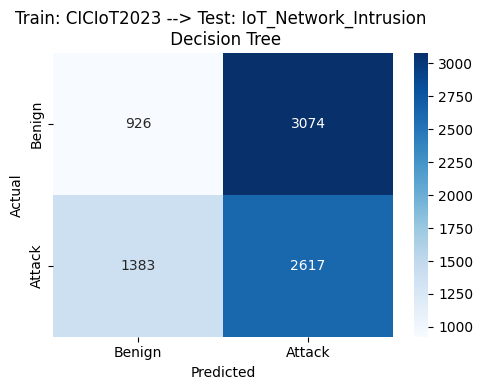


 [Random Forest]
Accuracy: 0.379625
F1 Score Weighted: 0.36402361486805274
F1 Score Attack: 0.463633416189344
F1 Score Benign: 0.2644138135467615
Training time: 8.001208782196045 sec
Testing time: 0.12926197052001953 sec


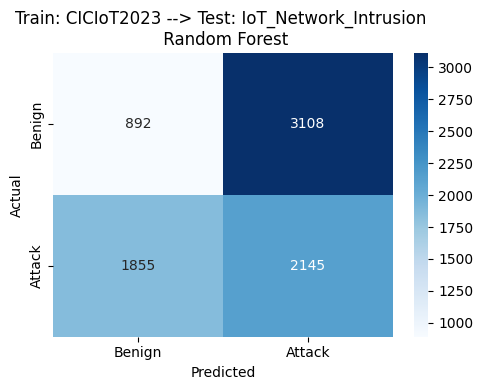


 [KNN]
Accuracy: 0.313875
F1 Score Weighted: 0.3135465212845991
F1 Score Attack: 0.2985303514376997
F1 Score Benign: 0.3285626911314985
Training time: 0.033803701400756836 sec
Testing time: 5.350280284881592 sec


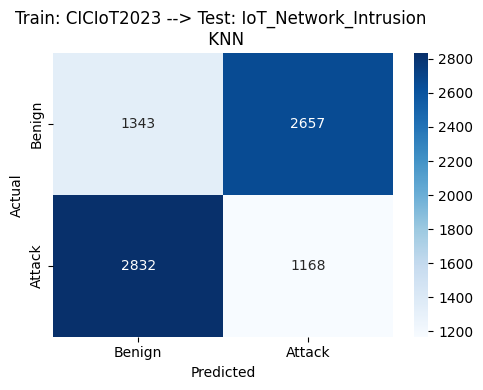


 [SVM]
Accuracy: 0.146
F1 Score Weighted: 0.1459909795297213
F1 Score Attack: 0.1487665088462497
F1 Score Benign: 0.14321545021319287
Training time: 183.92104029655457 sec
Testing time: 5.493811845779419 sec


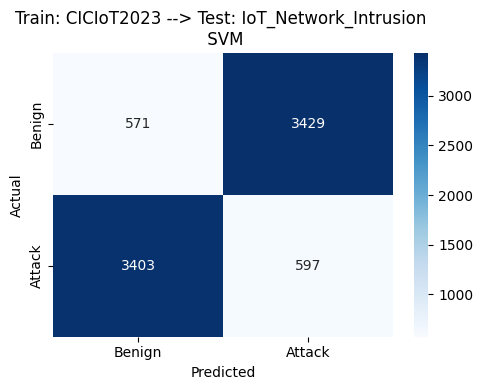


 [Logistic Regression]
Accuracy: 0.079
F1 Score Weighted: 0.07899792774533743
F1 Score Attack: 0.08037943085371942
F1 Score Benign: 0.07761642463695544
Training time: 2.79244065284729 sec
Testing time: 0.00414586067199707 sec


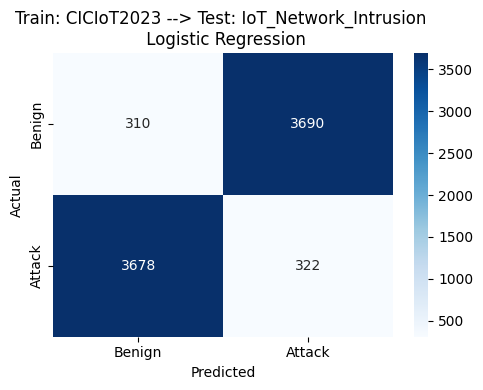


 [XGBoost]
Accuracy: 0.17775
F1 Score Weighted: 0.16721000158252888
F1 Score Attack: 0.2608988764044944
F1 Score Benign: 0.07352112676056338
Training time: 4.786733388900757 sec
Testing time: 0.017238855361938477 sec


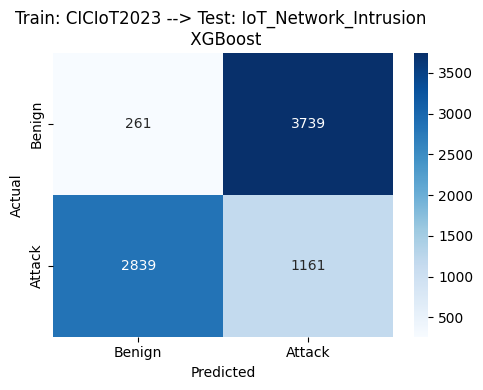


 [DNN]
Accuracy: 0.19575
F1 Score Weighted: 0.18439349502472424
F1 Score Attack: 0.2806350626118068
F1 Score Benign: 0.08815192743764172
Training time: 40.9245719909668 sec
Testing time: 0.008728981018066406 sec


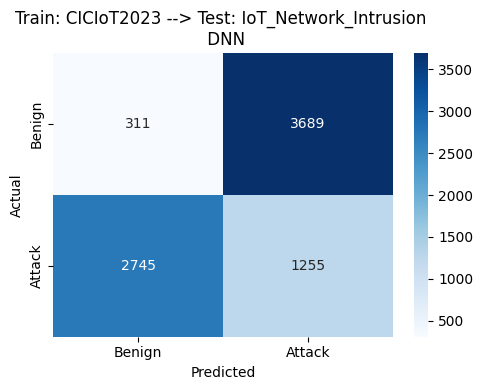

Train: CICIoT2023 --> Test: UQIoT

Training size: 32000 rows
Attack: 16000
Benign: 16000

 Testing size: 7061 rows
Attack: 3061
Benign: 4000

 [Decision Tree]
Accuracy: 0.4166548647500354
F1 Score Weighted: 0.3948965193137294
F1 Score Attack: 0.20712223291626564
F1 Score Benign: 0.5385907919793884
Training time: 3.7630434036254883 sec
Testing time: 0.004548311233520508 sec


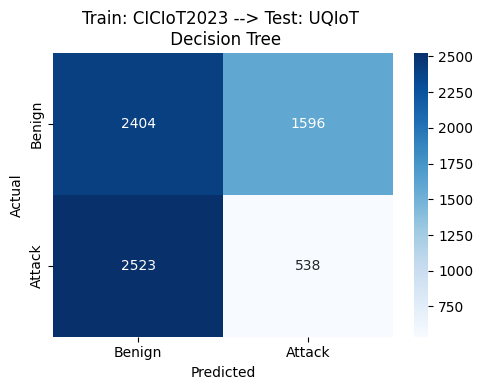


 [Random Forest]
Accuracy: 0.3207760940376717
F1 Score Weighted: 0.31019206321095866
F1 Score Attack: 0.3679493937796521
F1 Score Benign: 0.265993265993266
Training time: 8.00931692123413 sec
Testing time: 0.1551060676574707 sec


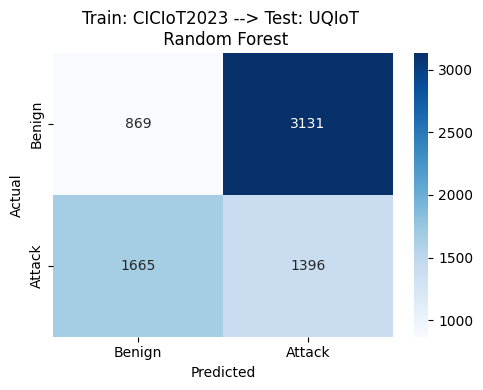


 [KNN]
Accuracy: 0.5493556153519331
F1 Score Weighted: 0.49409868795670225
F1 Score Attack: 0.2551498127340824
F1 Score Benign: 0.6769543147208121
Training time: 0.03565359115600586 sec
Testing time: 2.962535858154297 sec


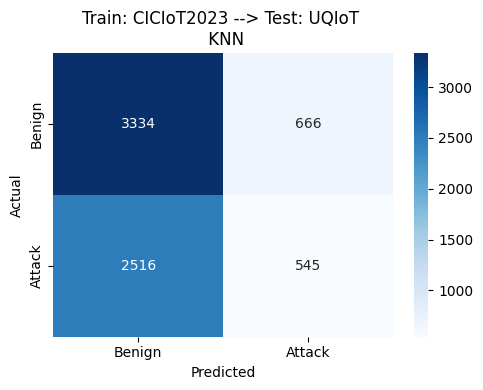


 [SVM]
Accuracy: 0.5033281404900156
F1 Score Weighted: 0.4485573409829507
F1 Score Attack: 0.19803338669105877
F1 Score Benign: 0.640270797004821
Training time: 197.75388622283936 sec
Testing time: 4.911088943481445 sec


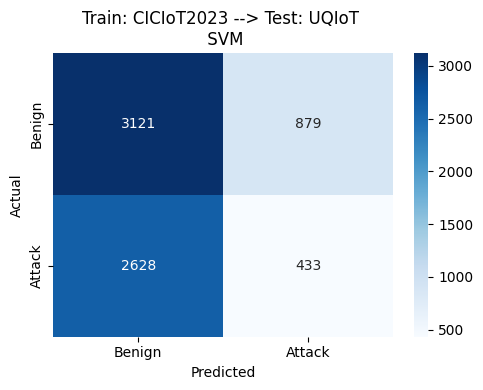


 [Logistic Regression]
Accuracy: 0.5918425152244725
F1 Score Weighted: 0.5889572496635562
F1 Score Attack: 0.6077844311377245
F1 Score Benign: 0.5745497490404488
Training time: 2.6965603828430176 sec
Testing time: 0.00444793701171875 sec


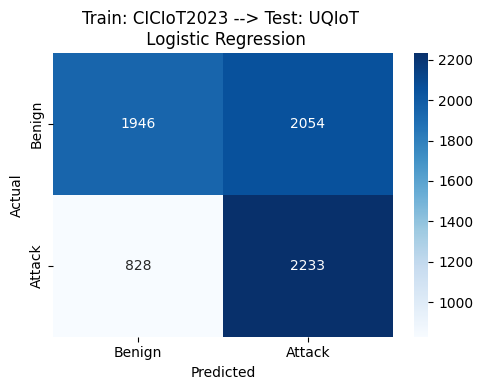


 [XGBoost]
Accuracy: 0.6456592550630222
F1 Score Weighted: 0.6064585603282519
F1 Score Attack: 0.4274599542334096
F1 Score Benign: 0.7434372436423298
Training time: 4.529521226882935 sec
Testing time: 0.013195037841796875 sec


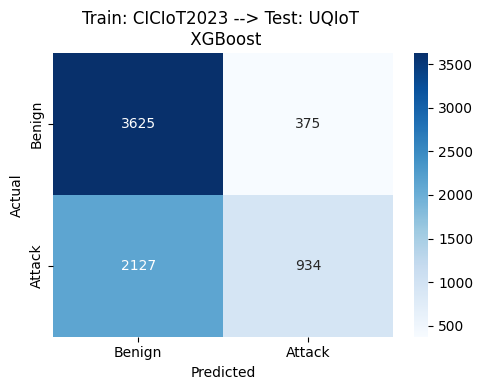


 [DNN]
Accuracy: 0.5684747202945758
F1 Score Weighted: 0.5703053770086143
F1 Score Attack: 0.5444760053819704
F1 Score Benign: 0.5900713036459034
Training time: 36.10352945327759 sec
Testing time: 0.007420778274536133 sec


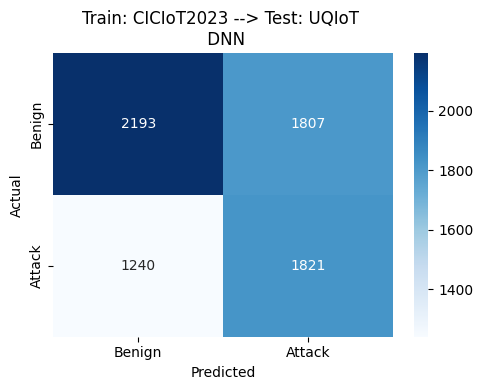

Train: CICIoT2023 --> Test: Mininet

Training size: 32000 rows
Attack: 16000
Benign: 16000

 Testing size: 8000 rows
Attack: 4000
Benign: 4000

 [Decision Tree]
Accuracy: 0.445375
F1 Score Weighted: 0.30813802646372046
F1 Score Attack: 0.0
F1 Score Benign: 0.6162760529274409
Training time: 3.849134922027588 sec
Testing time: 0.004477024078369141 sec


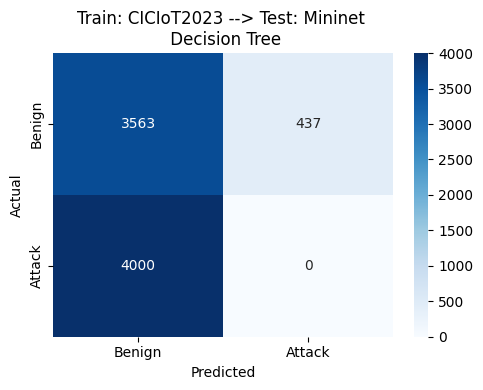


 [Random Forest]
Accuracy: 0.317375
F1 Score Weighted: 0.24198141768317782
F1 Score Attack: 0.002921307285010042
F1 Score Benign: 0.48104152808134565
Training time: 7.960937738418579 sec
Testing time: 0.12273931503295898 sec


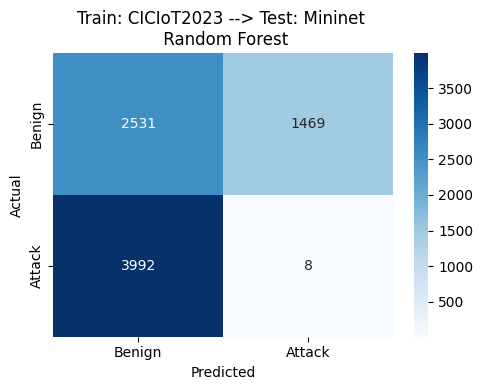


 [KNN]
Accuracy: 0.4045
F1 Score Weighted: 0.28800284798860804
F1 Score Attack: 0.0
F1 Score Benign: 0.5760056959772161
Training time: 0.02427959442138672 sec
Testing time: 2.642230272293091 sec


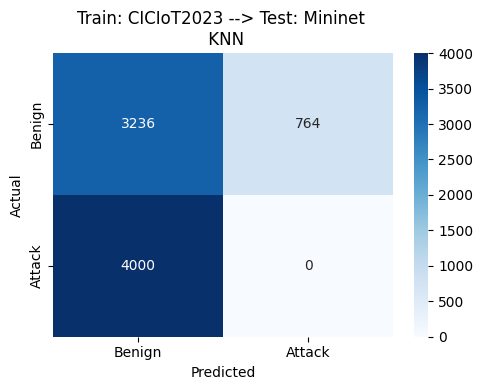


 [SVM]
Accuracy: 0.401875
F1 Score Weighted: 0.28666963887650476
F1 Score Attack: 0.0
F1 Score Benign: 0.5733392777530094
Training time: 195.52244329452515 sec
Testing time: 5.912349224090576 sec


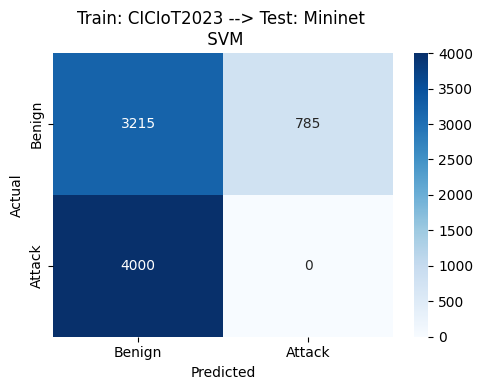


 [Logistic Regression]
Accuracy: 0.753625
F1 Score Weighted: 0.7377034301780688
F1 Score Attack: 0.8023267475679471
F1 Score Benign: 0.6730801127881905
Training time: 3.123530387878418 sec
Testing time: 0.011338472366333008 sec


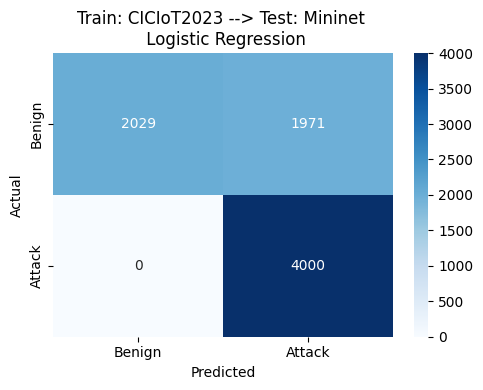


 [XGBoost]
Accuracy: 0.333
F1 Score Weighted: 0.24981245311327832
F1 Score Attack: 0.0
F1 Score Benign: 0.49962490622655664
Training time: 5.39874005317688 sec
Testing time: 0.017624855041503906 sec


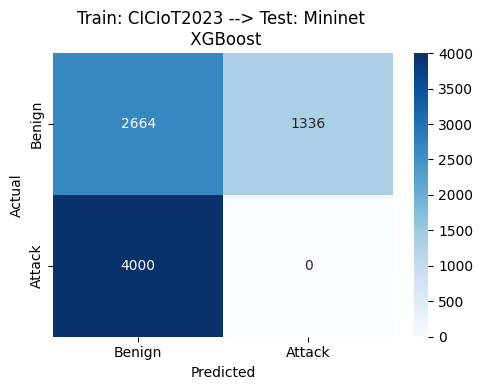


 [DNN]
Accuracy: 0.78
F1 Score Weighted: 0.7699008926537984
F1 Score Attack: 0.8181066556428276
F1 Score Benign: 0.7216951296647691
Training time: 40.473413944244385 sec
Testing time: 0.008204936981201172 sec


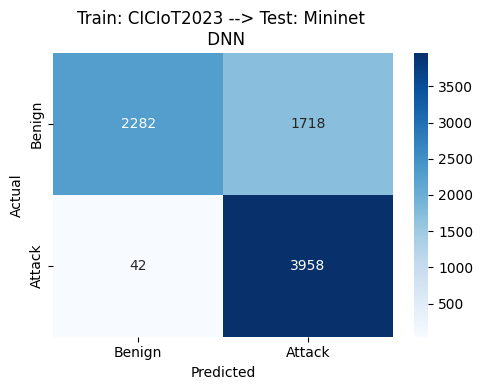

Train: IoT_Network_Intrusion --> Test: CICIoT2023

Training size: 32000 rows
Attack: 16000
Benign: 16000

 Testing size: 8000 rows
Attack: 4000
Benign: 4000

 [Decision Tree]
Accuracy: 0.153625
F1 Score Weighted: 0.14501086422421172
F1 Score Attack: 0.059191329720716966
F1 Score Benign: 0.23083039872770647
Training time: 1.634577751159668 sec
Testing time: 0.004630565643310547 sec


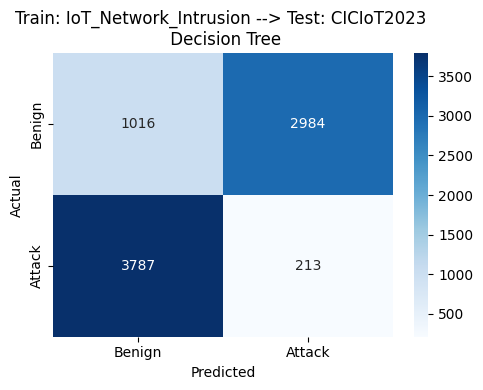


 [Random Forest]
Accuracy: 0.34475
F1 Score Weighted: 0.26696546004734517
F1 Score Attack: 0.02817945865776789
F1 Score Benign: 0.5057514614369225
Training time: 5.814319372177124 sec
Testing time: 0.1483621597290039 sec


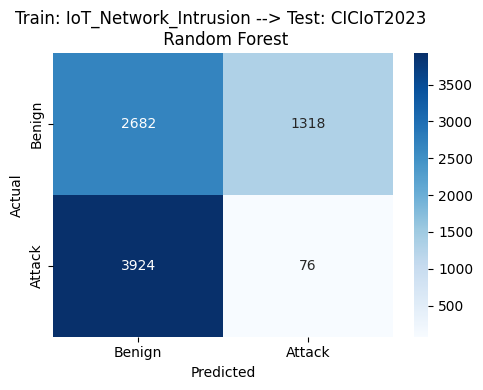


 [KNN]
Accuracy: 0.380125
F1 Score Weighted: 0.35849463178275864
F1 Score Attack: 0.4762910550216496
F1 Score Benign: 0.2406982085438677
Training time: 0.03768730163574219 sec
Testing time: 2.4943554401397705 sec


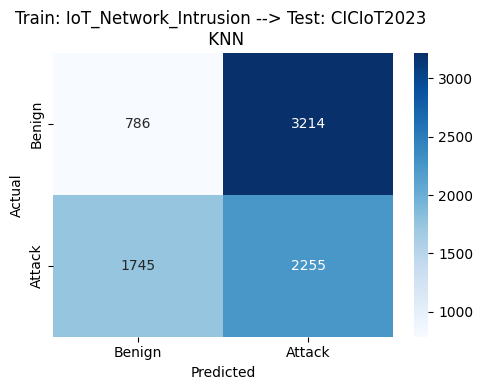


 [SVM]
Accuracy: 0.255625
F1 Score Weighted: 0.2544983489814349
F1 Score Attack: 0.22551697229808818
F1 Score Benign: 0.28347972566478163
Training time: 33.397395849227905 sec
Testing time: 1.072267770767212 sec


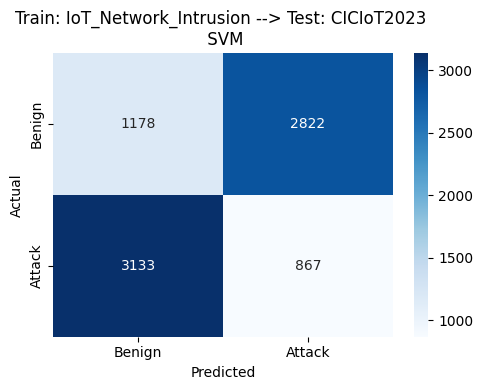


 [Logistic Regression]
Accuracy: 0.338
F1 Score Weighted: 0.290792298561444
F1 Score Attack: 0.4737678855325914
F1 Score Benign: 0.1078167115902965
Training time: 1.5296542644500732 sec
Testing time: 0.004689693450927734 sec


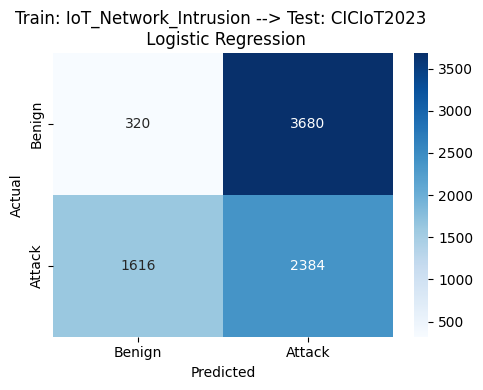


 [XGBoost]
Accuracy: 0.032
F1 Score Weighted: 0.03155233506688467
F1 Score Attack: 0.05237395986294665
F1 Score Benign: 0.010730710270822688
Training time: 2.8241143226623535 sec
Testing time: 0.012146949768066406 sec


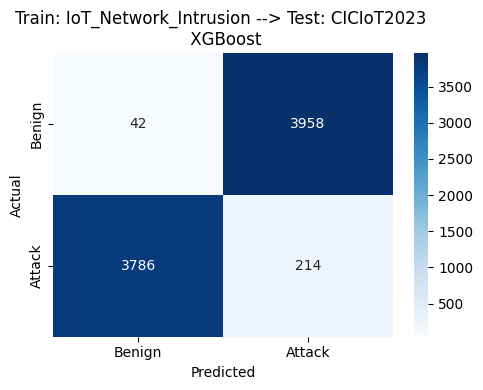


 [DNN]
Accuracy: 0.3535
F1 Score Weighted: 0.33927082556845606
F1 Score Attack: 0.24230881922062703
F1 Score Benign: 0.43623283191628515
Training time: 18.73210382461548 sec
Testing time: 0.007841110229492188 sec


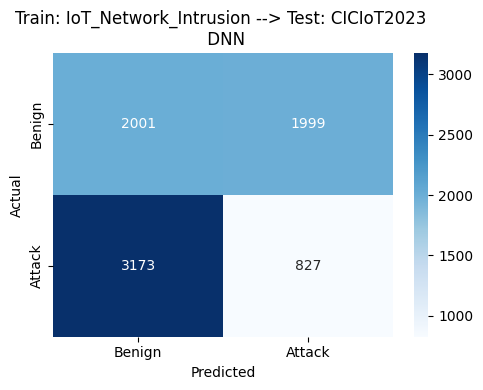

Train: IoT_Network_Intrusion --> Test: UQIoT

Training size: 32000 rows
Attack: 16000
Benign: 16000

 Testing size: 7061 rows
Attack: 3061
Benign: 4000

 [Decision Tree]
Accuracy: 0.3008072510975782
F1 Score Weighted: 0.25780140862150513
F1 Score Attack: 0.4105074626865672
F1 Score Benign: 0.14094310074821645
Training time: 1.4293839931488037 sec
Testing time: 0.003939390182495117 sec


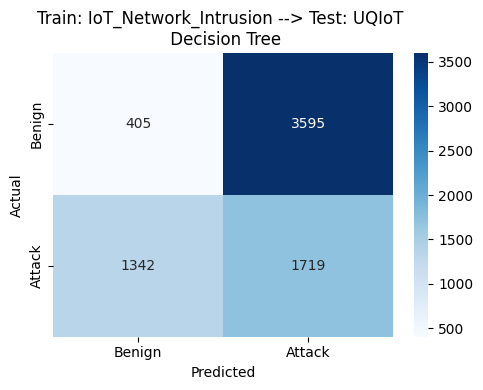


 [Random Forest]
Accuracy: 0.5798045602605864
F1 Score Weighted: 0.5312523529258145
F1 Score Attack: 0.3146223146223146
F1 Score Benign: 0.6970284897375677
Training time: 5.729043483734131 sec
Testing time: 0.13376927375793457 sec


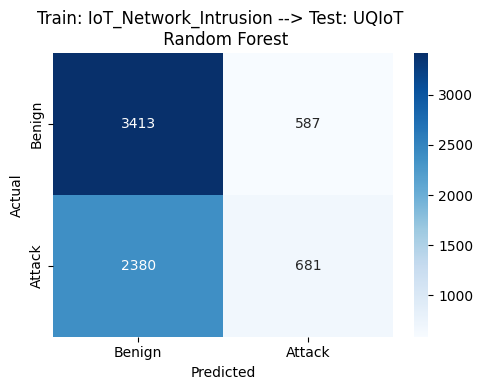


 [KNN]
Accuracy: 0.43110041070669874
F1 Score Weighted: 0.418210691887448
F1 Score Attack: 0.26361136571952337
F1 Score Benign: 0.5365178262374524
Training time: 0.02729940414428711 sec
Testing time: 2.1154162883758545 sec


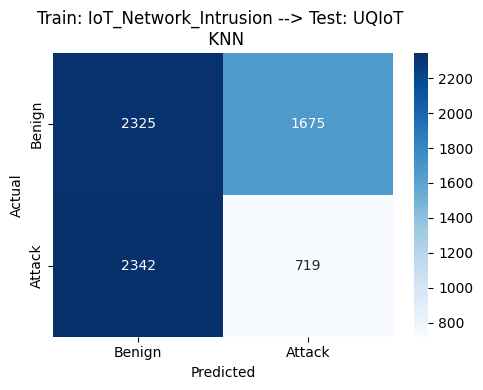


 [SVM]
Accuracy: 0.3669451918991644
F1 Score Weighted: 0.3566666175763578
F1 Score Attack: 0.41215149921094163
F1 Score Benign: 0.3142068119054925
Training time: 33.571983098983765 sec
Testing time: 1.0481603145599365 sec


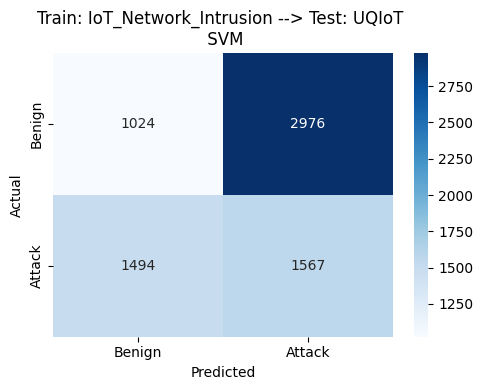


 [Logistic Regression]
Accuracy: 0.40192607279422177
F1 Score Weighted: 0.34609648389991343
F1 Score Attack: 0.5167639317999771
F1 Score Benign: 0.21549321939438976
Training time: 1.5105228424072266 sec
Testing time: 0.007091999053955078 sec


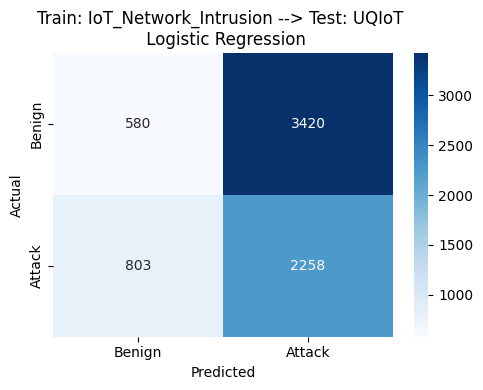


 [XGBoost]
Accuracy: 0.32290043903129867
F1 Score Weighted: 0.26822117138784285
F1 Score Attack: 0.4443927948866938
F1 Score Benign: 0.1334058365053471
Training time: 2.9636330604553223 sec
Testing time: 0.009401321411132812 sec


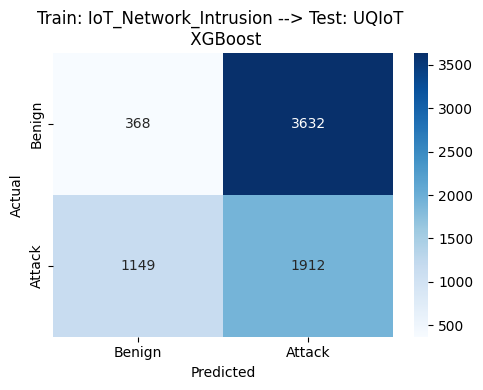


 [DNN]
Accuracy: 0.3513666619459
F1 Score Weighted: 0.3538870476542649
F1 Score Attack: 0.32208407341622264
F1 Score Benign: 0.37822427368992667
Training time: 19.23003101348877 sec
Testing time: 0.009345054626464844 sec


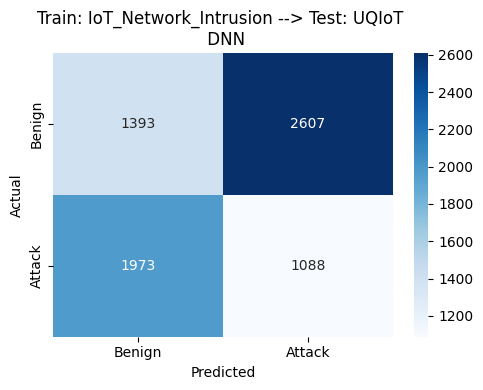

Train: IoT_Network_Intrusion --> Test: Mininet

Training size: 32000 rows
Attack: 16000
Benign: 16000

 Testing size: 8000 rows
Attack: 4000
Benign: 4000

 [Decision Tree]
Accuracy: 0.767875
F1 Score Weighted: 0.7546553349228
F1 Score Attack: 0.811605965303845
F1 Score Benign: 0.6977047045417548
Training time: 1.4874968528747559 sec
Testing time: 0.00501251220703125 sec


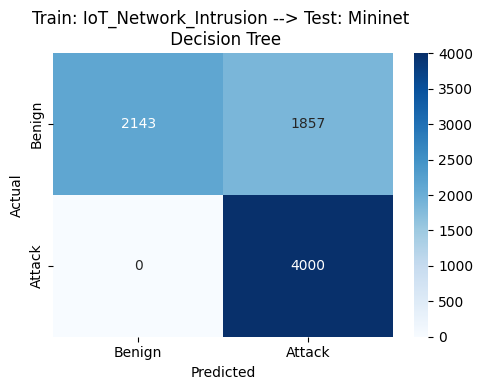


 [Random Forest]
Accuracy: 0.2935
F1 Score Weighted: 0.2319909208608224
F1 Score Attack: 0.014644351464435146
F1 Score Benign: 0.44933749025720965
Training time: 5.792577743530273 sec
Testing time: 0.11078000068664551 sec


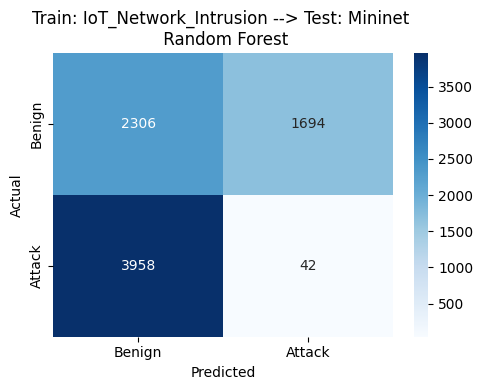


 [KNN]
Accuracy: 0.3245
F1 Score Weighted: 0.27612933334512096
F1 Score Attack: 0.08900876601483479
F1 Score Benign: 0.4632499006754072
Training time: 0.04213738441467285 sec
Testing time: 2.5606985092163086 sec


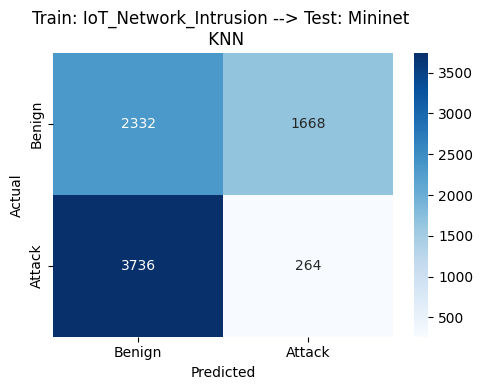


 [SVM]
Accuracy: 0.76375
F1 Score Weighted: 0.7497844538698184
F1 Score Attack: 0.8088978766430738
F1 Score Benign: 0.690671031096563
Training time: 32.99458575248718 sec
Testing time: 1.1394286155700684 sec


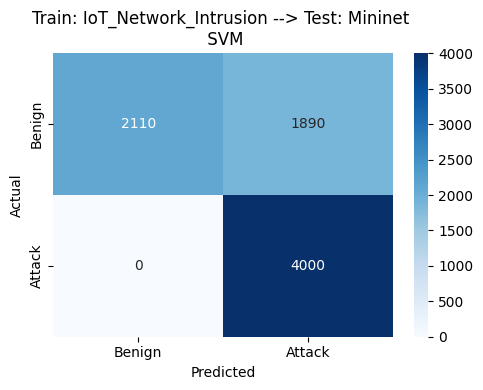


 [Logistic Regression]
Accuracy: 0.592125
F1 Score Weighted: 0.5107288683518968
F1 Score Attack: 0.7102903311728669
F1 Score Benign: 0.31116740553092676
Training time: 1.7242977619171143 sec
Testing time: 0.00567317008972168 sec


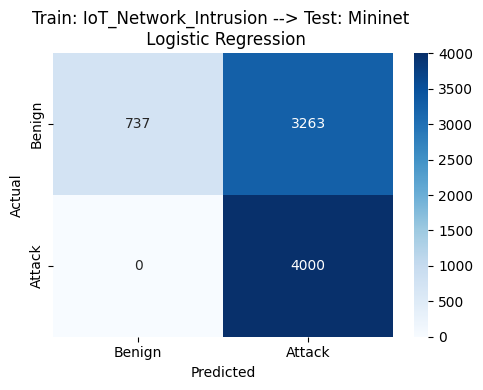


 [XGBoost]
Accuracy: 0.63975
F1 Score Weighted: 0.5860241940273864
F1 Score Attack: 0.7351589781290204
F1 Score Benign: 0.43688940992575226
Training time: 2.9357497692108154 sec
Testing time: 0.009398698806762695 sec


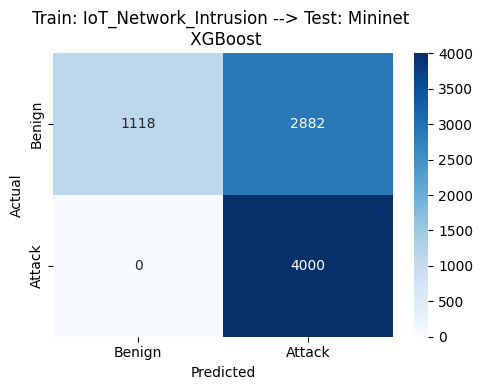


 [DNN]
Accuracy: 0.8275
F1 Score Weighted: 0.8222569236241221
F1 Score Attack: 0.8527842969916791
F1 Score Benign: 0.791729550256565
Training time: 18.454293489456177 sec
Testing time: 0.008123159408569336 sec


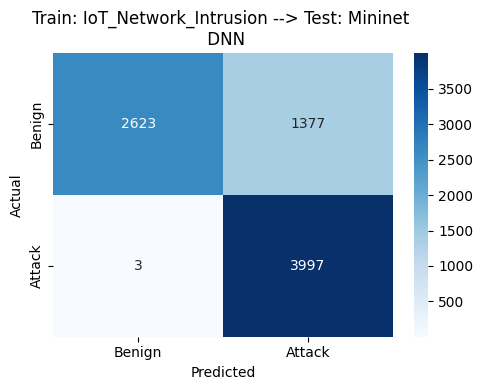

Train: UQIoT --> Test: CICIoT2023

Training size: 24482 rows
Attack: 12241
Benign: 12241

 Testing size: 8000 rows
Attack: 4000
Benign: 4000

 [Decision Tree]
Accuracy: 0.08075
F1 Score Weighted: 0.07764720519828704
F1 Score Attack: 0.1311436672967864
F1 Score Benign: 0.024150743099787687
Training time: 3.0967562198638916 sec
Testing time: 0.0051021575927734375 sec


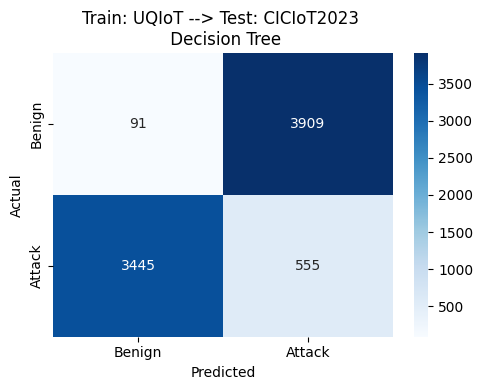


 [Random Forest]
Accuracy: 0.192375
F1 Score Weighted: 0.17071180244060186
F1 Score Attack: 0.3047455073711396
F1 Score Benign: 0.03667809751006411
Training time: 6.243143081665039 sec
Testing time: 0.13825201988220215 sec


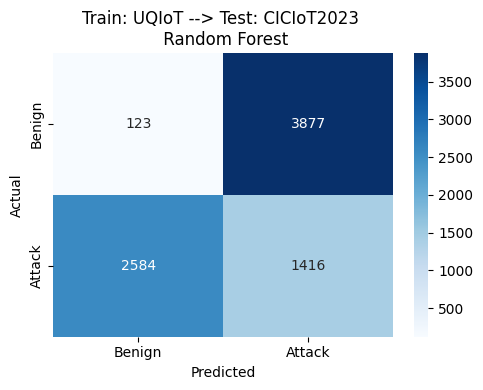


 [KNN]
Accuracy: 0.2925
F1 Score Weighted: 0.2904116370987088
F1 Score Attack: 0.25191646841131377
F1 Score Benign: 0.3289068057861039
Training time: 0.025581836700439453 sec
Testing time: 1.937270164489746 sec


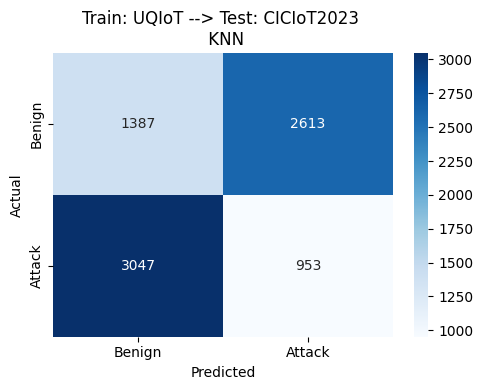


 [SVM]
Accuracy: 0.583375
F1 Score Weighted: 0.5745059420203706
F1 Score Attack: 0.6359366466411797
F1 Score Benign: 0.5130752373995617
Training time: 403.6932120323181 sec
Testing time: 21.10357689857483 sec


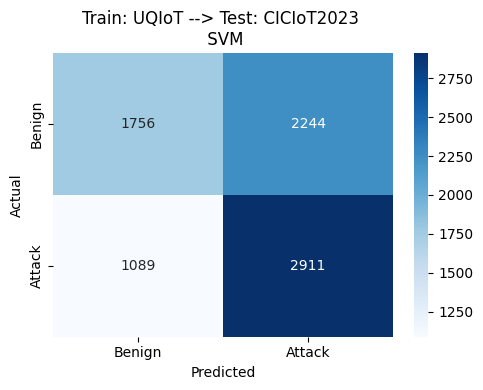


 [Logistic Regression]
Accuracy: 0.141
F1 Score Weighted: 0.13296775913107525
F1 Score Attack: 0.049515905947441215
F1 Score Benign: 0.21641961231470924
Training time: 4.7397167682647705 sec
Testing time: 0.0044324398040771484 sec


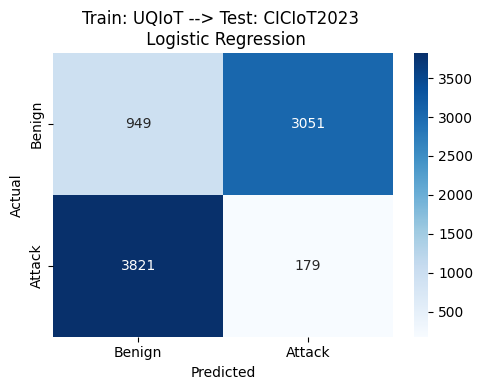


 [XGBoost]
Accuracy: 0.2775
F1 Score Weighted: 0.2360245360369077
F1 Score Attack: 0.4140308191403082
F1 Score Benign: 0.058018252933507174
Training time: 3.1220693588256836 sec
Testing time: 0.013150930404663086 sec


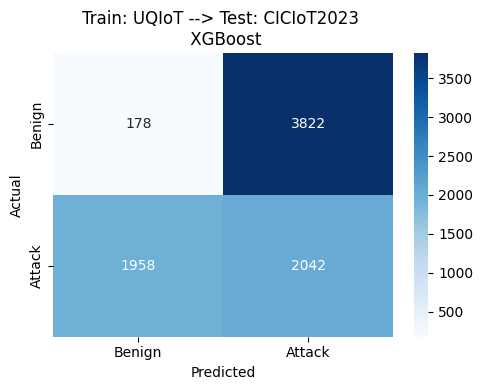


 [DNN]
Accuracy: 0.363625
F1 Score Weighted: 0.3625071463202468
F1 Score Attack: 0.33581213307240704
F1 Score Benign: 0.3892021595680864
Training time: 29.630987644195557 sec
Testing time: 0.011034250259399414 sec


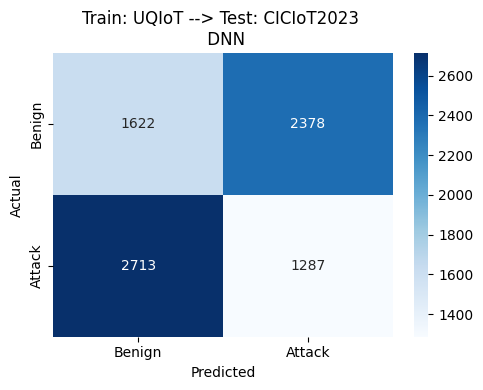

Train: UQIoT --> Test: IoT_Network_Intrusion

Training size: 24482 rows
Attack: 12241
Benign: 12241

 Testing size: 8000 rows
Attack: 4000
Benign: 4000

 [Decision Tree]
Accuracy: 0.73775
F1 Score Weighted: 0.7370389533298038
F1 Score Attack: 0.750712927756654
F1 Score Benign: 0.7233649789029536
Training time: 2.9172887802124023 sec
Testing time: 0.004346132278442383 sec


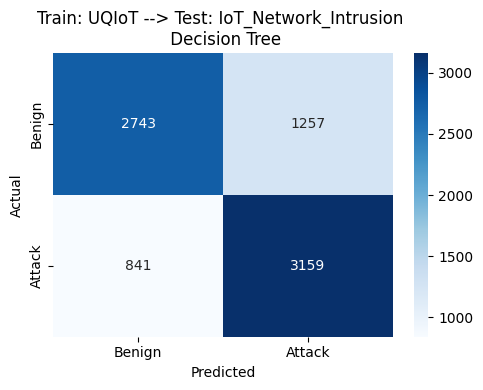


 [Random Forest]
Accuracy: 0.516875
F1 Score Weighted: 0.3991603674208195
F1 Score Attack: 0.6651070097911793
F1 Score Benign: 0.13321372505045975
Training time: 6.239678621292114 sec
Testing time: 0.1123647689819336 sec


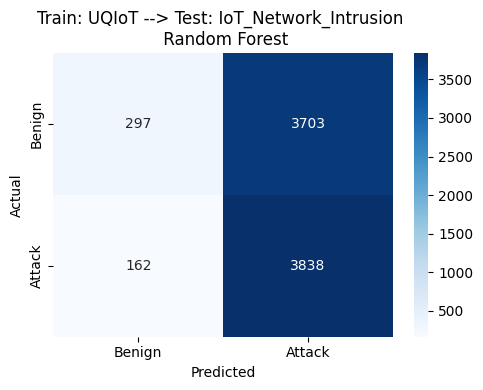


 [KNN]
Accuracy: 0.497625
F1 Score Weighted: 0.452058072232523
F1 Score Attack: 0.6100708256524692
F1 Score Benign: 0.29404531881257684
Training time: 0.020222902297973633 sec
Testing time: 2.1218185424804688 sec


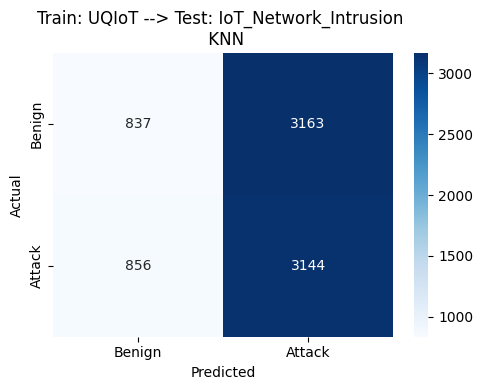


 [SVM]
Accuracy: 0.3055
F1 Score Weighted: 0.24744402204598923
F1 Score Attack: 0.4564664449227157
F1 Score Benign: 0.03842159916926272
Training time: 396.22221326828003 sec
Testing time: 22.179900646209717 sec


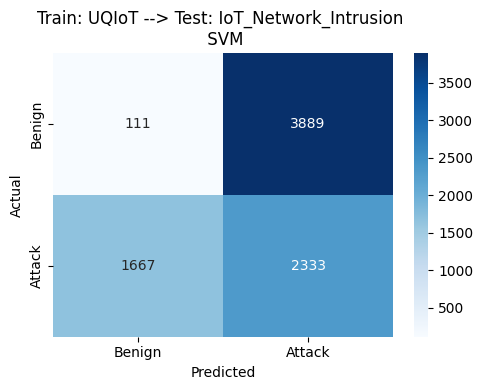


 [Logistic Regression]
Accuracy: 0.912875
F1 Score Weighted: 0.9128439492951231
F1 Score Attack: 0.9111988788380685
F1 Score Benign: 0.9144890197521777
Training time: 4.704742431640625 sec
Testing time: 0.00554966926574707 sec


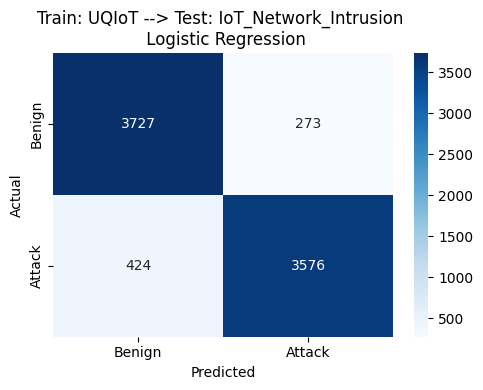


 [XGBoost]
Accuracy: 0.763
F1 Score Weighted: 0.7517642121371196
F1 Score Attack: 0.8045763760049475
F1 Score Benign: 0.6989520482692918
Training time: 3.3132855892181396 sec
Testing time: 0.012893199920654297 sec


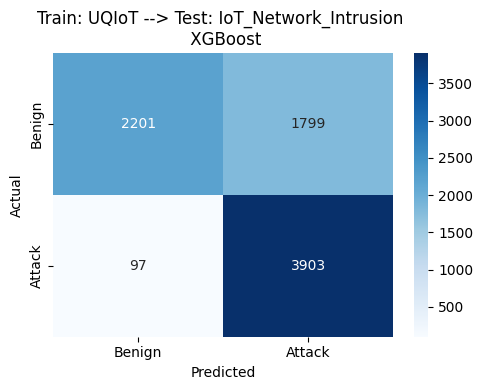


 [DNN]
Accuracy: 0.6265
F1 Score Weighted: 0.6264568324176962
F1 Score Attack: 0.6224412433661866
F1 Score Benign: 0.630472421469206
Training time: 29.071508407592773 sec
Testing time: 0.011624574661254883 sec


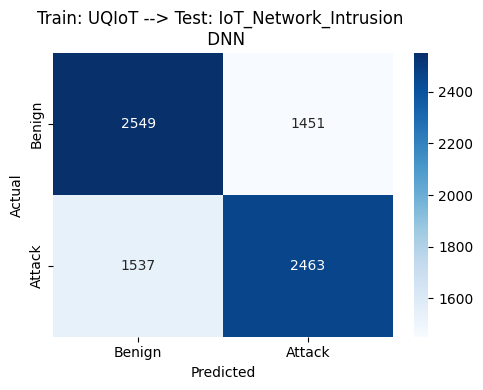

Train: UQIoT --> Test: Mininet

Training size: 24482 rows
Attack: 12241
Benign: 12241

 Testing size: 8000 rows
Attack: 4000
Benign: 4000

 [Decision Tree]
Accuracy: 0.623875
F1 Score Weighted: 0.5619924039744495
F1 Score Attack: 0.7266285091305533
F1 Score Benign: 0.39735629881834567
Training time: 3.029202938079834 sec
Testing time: 0.004446744918823242 sec


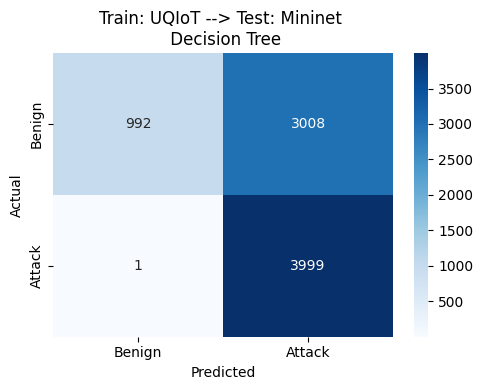


 [Random Forest]
Accuracy: 0.672125
F1 Score Weighted: 0.6532390495200384
F1 Score Attack: 0.7341643863382994
F1 Score Benign: 0.5723137127017772
Training time: 6.459959030151367 sec
Testing time: 0.15090489387512207 sec


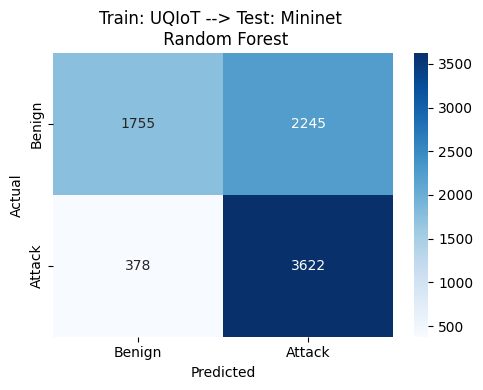


 [KNN]
Accuracy: 0.295
F1 Score Weighted: 0.2627176788470107
F1 Score Attack: 0.10844135314574771
F1 Score Benign: 0.41699400454827373
Training time: 0.02238178253173828 sec
Testing time: 1.9779407978057861 sec


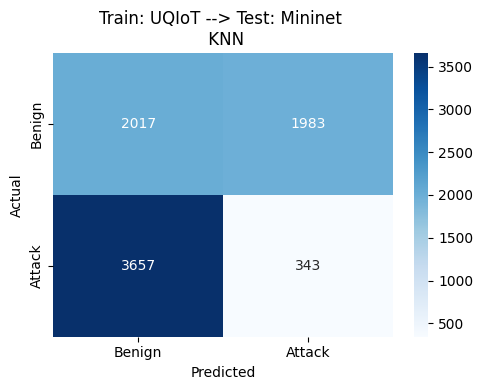


 [SVM]
Accuracy: 0.686
F1 Score Weighted: 0.651654530044242
F1 Score Attack: 0.76103500761035
F1 Score Benign: 0.5422740524781341
Training time: 400.6249632835388 sec
Testing time: 23.400448083877563 sec


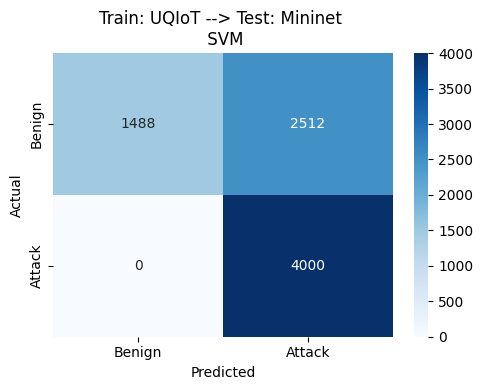


 [Logistic Regression]
Accuracy: 0.785125
F1 Score Weighted: 0.7747237085064358
F1 Score Attack: 0.8231299516411154
F1 Score Benign: 0.7263174653717561
Training time: 4.651977062225342 sec
Testing time: 0.00672149658203125 sec


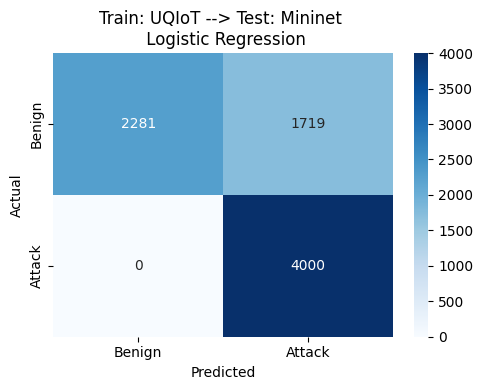


 [XGBoost]
Accuracy: 0.2045
F1 Score Weighted: 0.16986852316623155
F1 Score Attack: 0.00031416902293433867
F1 Score Benign: 0.33942287730952875
Training time: 3.4164185523986816 sec
Testing time: 0.013089656829833984 sec


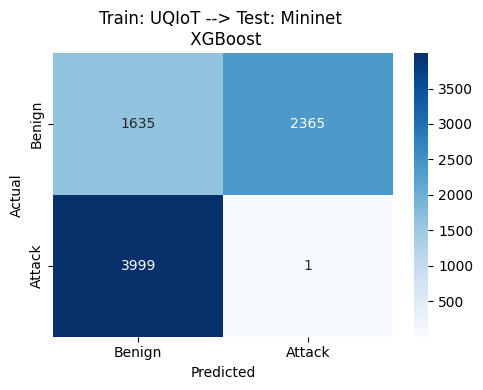


 [DNN]
Accuracy: 0.617375
F1 Score Weighted: 0.5517504129898366
F1 Score Attack: 0.7232619112196004
F1 Score Benign: 0.3802389147600729
Training time: 28.893078327178955 sec
Testing time: 0.0077359676361083984 sec


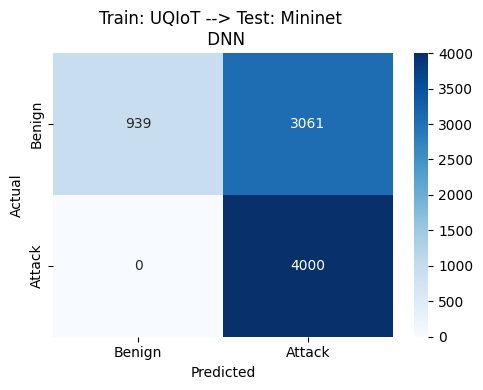

All 6 Combination of Cross-dataset evaluaion is done
Trained models stored for 9 combinations
{'CICIoT2023 -> IoT_Network_Intrusion': ({'Decision Tree': DecisionTreeClassifier(random_state=42), 'Random Forest': RandomForestClassifier(n_jobs=-1, random_state=42), 'KNN': KNeighborsClassifier(n_jobs=-1), 'SVM': SVC(probability=True, random_state=42), 'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42), 'XGBoost': XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_

In [7]:
# Run all 6 Cross-dataset combination

feature_columns=ciciot_features

all_results=[]

trained_combinations={}

# Combination 1: Train on CICIoT2023 Dataset and Test on IoT Network Intrusion Dataset
results, models_1, X_train_1, X_test_1, scaler_1= run_cross_dataset(ciciot_train, iot_nid_test, "CICIoT2023", "IoT_Network_Intrusion", feature_columns)
all_results.extend(results)
trained_combinations["CICIoT2023 -> IoT_Network_Intrusion"] = (models_1, X_train_1, X_test_1)

# Combination 2: Train on CICIoT2023 Dataset and Test on UQIoT Dataset
results, models_2, X_train_2, X_test_2, scaler_2= run_cross_dataset(ciciot_train, uqiot_test, "CICIoT2023", "UQIoT", feature_columns)
all_results.extend(results)
trained_combinations["CICIoT2023 -> UQIoT"] = (models_2, X_train_2, X_test_2)

# Combination 3: Train on CICIoT2023 Dataset and Test on Mininet Dataset
results, models_3, X_train_3, X_test_3, scaler_3= run_cross_dataset(ciciot_train, mininet_test, "CICIoT2023", "Mininet", feature_columns)
all_results.extend(results)
trained_combinations["CICIoT2023 -> Mininet"] = (models_3, X_train_3, X_test_3)

# Combination 4: Train on IOT_Network_Intrusion_Dataset and Test on CICIOT2023
results, models_4, X_train_4, X_test_4, scaler_4= run_cross_dataset(iot_nid_train, ciciot_test, "IoT_Network_Intrusion", "CICIoT2023", feature_columns)
all_results.extend(results)
trained_combinations["IoT_Network_Intrusion -> CICIoT2023"] = (models_4, X_train_4, X_test_4)

# Combination 5: Train on IOT_Network_Intrusion_Dataset and Test on UQIOT Dataset
results, models_5, X_train_5, X_test_5, scaler_5= run_cross_dataset(iot_nid_train, uqiot_test, "IoT_Network_Intrusion" , "UQIoT", feature_columns)
all_results.extend(results)
trained_combinations["IoT_Network_Intrusion -> UQIoT"] = (models_5, X_train_5, X_test_5)

# Combination 6: Train on IoT_Network Intrusion Dataset and Test on Mininet Dataset
results, models_6, X_train_6, X_test_6, scaler_6= run_cross_dataset(iot_nid_train, mininet_test, "IoT_Network_Intrusion", "Mininet", feature_columns)
all_results.extend(results)
trained_combinations["IoT_Network_Intrusion -> Mininet"] = (models_6, X_train_6, X_test_6)

# Combination 7: Train on UQIoT Dataset and Test on CICIoT2023 Dataset
results, models_7, X_train_7, X_test_7, scaler_7= run_cross_dataset(uqiot_train, ciciot_test, "UQIoT", "CICIoT2023", feature_columns)
all_results.extend(results)
trained_combinations["UQIoT -> CICIoT2023"] = (models_7, X_train_7, X_test_7)

# Combination 8: Train on UQIoT Dataset and Test on IoT Network Intrusion Dataset
results, models_8, X_train_8, X_test_8, scaler_8= run_cross_dataset(uqiot_train, iot_nid_test, "UQIoT", "IoT_Network_Intrusion", feature_columns)
all_results.extend(results)
trained_combinations["UQIoT -> IoT_Network_Intrusion"] = (models_8, X_train_8, X_test_8)

# Combination 9: Train on UQIoT Dataset and Test on Mininet Dataset
results, models_9, X_train_9, X_test_9, scaler_9= run_cross_dataset(uqiot_train, mininet_test, "UQIoT", "Mininet", feature_columns)
all_results.extend(results)
trained_combinations["UQIoT -> Mininet"] = (models_9, X_train_9, X_test_9)

print("All 6 Combination of Cross-dataset evaluaion is done")
print(f"Trained models stored for {len(trained_combinations)} combinations")
print(trained_combinations)
print(all_results)

In [8]:
import joblib

best_cross_dataset_model=models_6['DNN']
joblib.dump(best_cross_dataset_model, "best_cross_dataset_model_dnn.pkl")

joblib.dump(scaler_6, "scaler.pkl")

joblib.dump(ciciot_features, "final_feature_columns.pkl")

print("Best model pickle file is exported.")

Best model pickle file is exported.


In [9]:
# Save the results in CSV

results_df=pd.DataFrame(all_results)
results_csv_path=os.path.join(Output_Dir, "cross_dataset_evaluation_results.csv")
results_df.to_csv(results_csv_path, index=False)

print(f"Results saved in: {results_csv_path}")
print(f"Total number of rows in results table: {len(results_df)}")
print("(9 comnibations X 6 models = 54 rows)")
print(results_df.to_string(index=False))


Results saved in: C:\Users\NARASIMHA N\Documents\comparative_analysis_arp_spoofing\Kitsune Feature Extraction\Dataset Preprocessing\Cross-Dataset Evaluation\Outputs\cross_dataset_evaluation_results.csv
Total number of rows in results table: 63
(9 comnibations X 6 models = 54 rows)
        Train Dataset          Test Dataset               Model  Accuracy  F1 Weighted  F1 Attack  F1 Benign  Training time  Testing time
           CICIoT2023 IoT_Network_Intrusion       Decision Tree  0.442875     0.416819   0.540089   0.293549       3.839137      0.012841
           CICIoT2023 IoT_Network_Intrusion       Random Forest  0.379625     0.364024   0.463633   0.264414       8.001209      0.129262
           CICIoT2023 IoT_Network_Intrusion                 KNN  0.313875     0.313547   0.298530   0.328563       0.033804      5.350280
           CICIoT2023 IoT_Network_Intrusion                 SVM  0.146000     0.145991   0.148767   0.143215     183.921040      5.493812
           CICIoT2023 IoT_Ne

In [10]:
#Finding the best model per combination

best_per_combination= (
    results_df.sort_values('F1 Weighted',ascending=False).groupby(['Train Dataset', 'Test Dataset'],sort=False).first().reset_index()
)[["Train Dataset", "Test Dataset", "Model", "Accuracy", "F1 Weighted", "F1 Attack", "F1 Benign"]]

print("Best model per cross-dataset combination:\n")
print(best_per_combination.to_string(index=False))

Best model per cross-dataset combination:

        Train Dataset          Test Dataset               Model  Accuracy  F1 Weighted  F1 Attack  F1 Benign
                UQIoT IoT_Network_Intrusion Logistic Regression  0.912875     0.912844   0.911199   0.914489
IoT_Network_Intrusion               Mininet                 DNN  0.827500     0.822257   0.852784   0.791730
                UQIoT               Mininet Logistic Regression  0.785125     0.774724   0.823130   0.726317
           CICIoT2023               Mininet                 DNN  0.780000     0.769901   0.818107   0.721695
           CICIoT2023                 UQIoT             XGBoost  0.645659     0.606459   0.427460   0.743437
                UQIoT            CICIoT2023                 SVM  0.583375     0.574506   0.635937   0.513075
IoT_Network_Intrusion                 UQIoT       Random Forest  0.579805     0.531252   0.314622   0.697028
           CICIoT2023 IoT_Network_Intrusion       Decision Tree  0.442875     0.41681

Model,Decision Tree,Random Forest,KNN,SVM,Logistic Regression,XGBoost,DNN
Combinations,,,,,,,
CICIoT2023-->IoT_Network_Intrusion,0.4168,0.3640,0.3135,0.1460,0.0790,0.1672,0.1844
CICIoT2023-->Mininet,0.3081,0.2420,0.2880,0.2867,0.7377,0.2498,0.7699
CICIoT2023-->UQIoT,0.3949,0.3102,0.4941,0.4486,0.5890,0.6065,0.5703
IoT_Network_Intrusion-->CICIoT2023,0.1450,0.2670,0.3585,0.2545,0.2908,0.0316,0.3393
IoT_Network_Intrusion-->Mininet,0.7547,0.2320,0.2761,0.7498,0.5107,0.5860,0.8223
IoT_Network_Intrusion-->UQIoT,0.2578,0.5313,0.4182,0.3567,0.3461,0.2682,0.3539
UQIoT-->CICIoT2023,0.0776,0.1707,0.2904,0.5745,0.1330,0.2360,0.3625
UQIoT-->IoT_Network_Intrusion,0.7370,0.3992,0.4521,0.2474,0.9128,0.7518,0.6265
UQIoT-->Mininet,0.5620,0.6532,0.2627,0.6517,0.7747,0.1699,0.5518


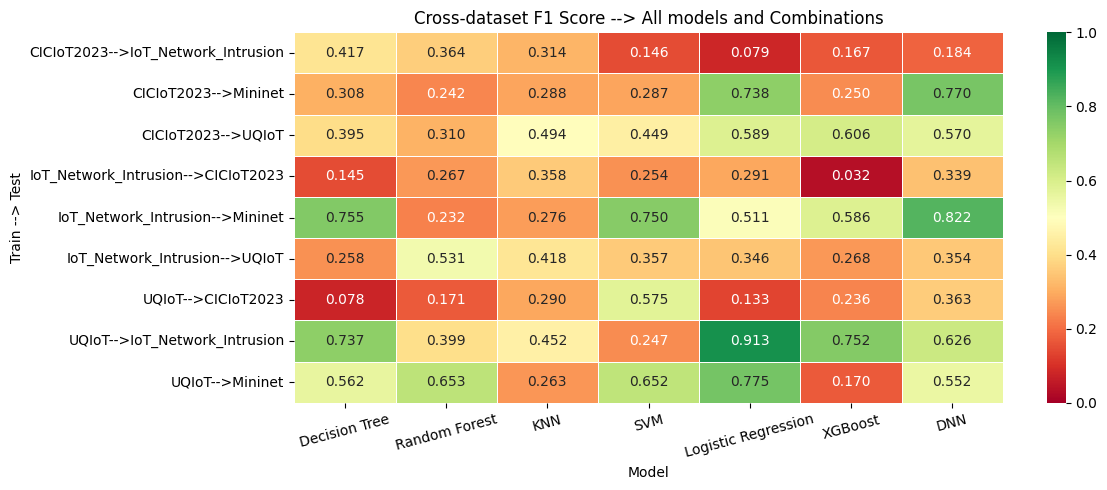

Heatmap saved to C:\Users\NARASIMHA N\Documents\comparative_analysis_arp_spoofing\Kitsune Feature Extraction\Dataset Preprocessing\Cross-Dataset Evaluation\Outputs\Cross-dataset_heatmap.png


In [11]:
#Creating a table with train --> test combinations as rows and models as columns to easily see which model generalize best accross all combinations

results_df['Combinations']=results_df['Train Dataset'] + "-->" + results_df["Test Dataset"]

#using pivot to create a table thta contains combinations as rows, models as columns and F1 scores as values
pivot=results_df.pivot(index='Combinations', columns="Model", values="F1 Weighted")

#reorder the columns to match within-dataset notebook order
model_order=["Decision Tree", "Random Forest", "KNN", "SVM", "Logistic Regression", "XGBoost", "DNN"]

pivot=pivot[model_order]

display(pivot.round(4))

fig, ax = plt.subplots(figsize=(12,5))
sbn.heatmap(
    pivot,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    vmin=0,
    vmax=1,
    linewidths=0.5,
    ax=ax
)

ax.set_title('Cross-dataset F1 Score --> All models and Combinations')
ax.set_xlabel('Model')
ax.set_ylabel('Train --> Test')
ax.tick_params(axis='x', rotation =15)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()

heatmap_path= os.path.join(Output_Dir, "Cross-dataset_heatmap.png")
plt.savefig(heatmap_path, dpi=150)
plt.show()
plt.close()

print(f"Heatmap saved to {heatmap_path}")

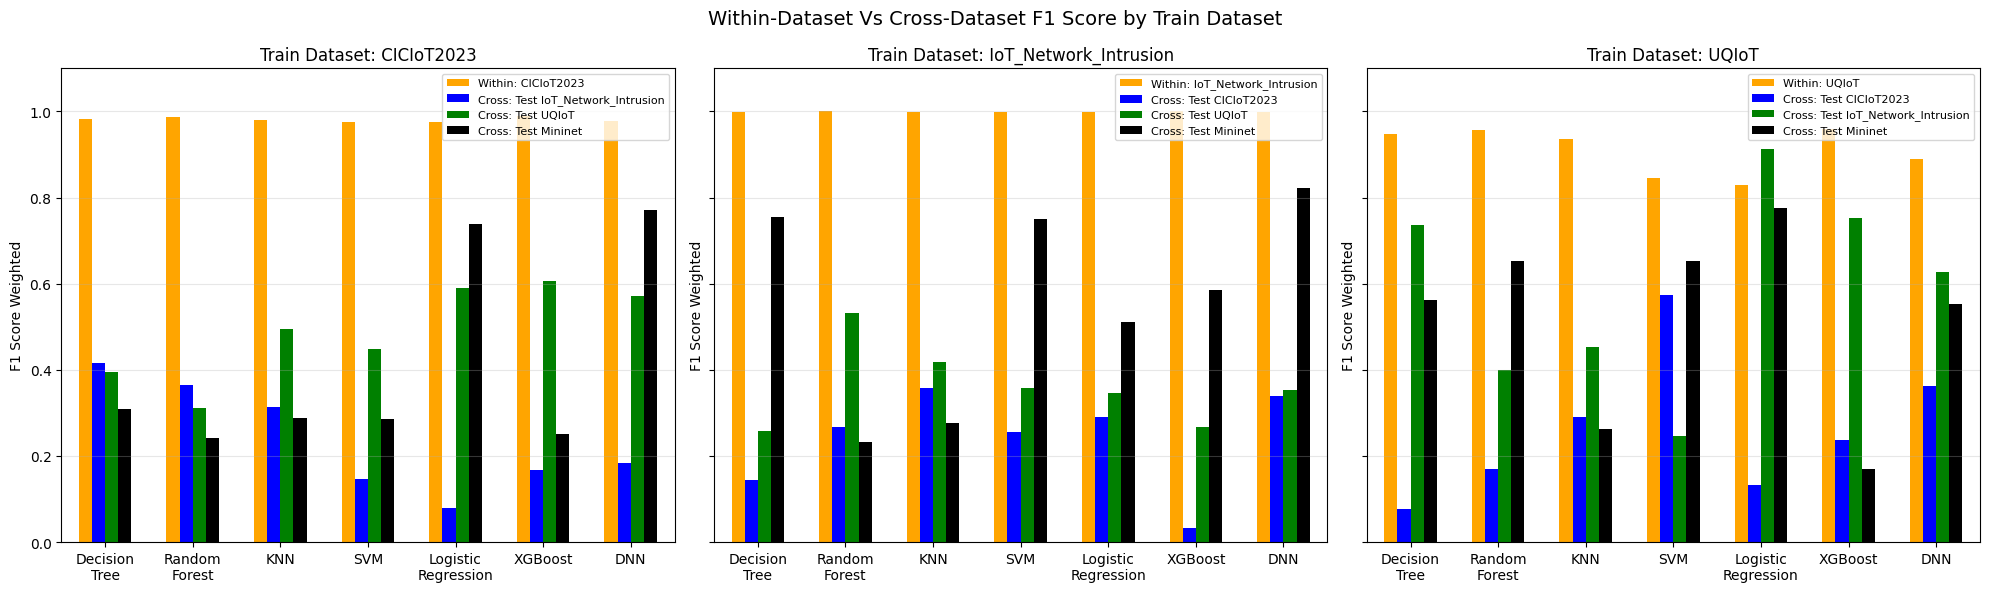

Bar chart sahve in: C:\Users\NARASIMHA N\Documents\comparative_analysis_arp_spoofing\Kitsune Feature Extraction\Dataset Preprocessing\Cross-Dataset Evaluation\Outputs\within_vs_cross_dataset_comparison.png


In [12]:
# Drawing bar chart to compare the performance of the models within dataset and cross dataset performance

within_dataset_scores = {
    "Decision Tree": {"CICIoT2023": 0.9832, "IoT_Network_Intrusion": 0.9995, "UQIoT": 0.9482, "Mininet":0.9998},
    "Random Forest": {"CICIoT2023": 0.9867, "IoT_Network_Intrusion": 0.9999, "UQIoT": 0.9574, "Mininet":0.9998},
    "KNN": {"CICIoT2023": 0.9803, "IoT_Network_Intrusion": 0.9991, "UQIoT":0.9360, "Mininet":0.9996},
    "SVM": {"CICIoT2023": 0.9743, "IoT_Network_Intrusion": 0.9991, "UQIoT": 0.8464, "Mininet":0.9991},
    "Logistic Regression": {"CICIoT2023": 0.9747, "IoT_Network_Intrusion": 0.9993, "UQIoT": 0.8283, "Mininet":0.9991},
    "XGBoost": {"CICIoT2023": 0.9886, "IoT_Network_Intrusion": 0.9999, "UQIoT": 0.9583, "Mininet":0.9998},
    "DNN":{"CICIoT2023": 0.9769, "IoT_Network_Intrusion": 0.9976 , "UQIoT": 0.8898, "Mininet":0.9992}
}

cross_test_targets = {
    "CICIoT2023": ["IoT_Network_Intrusion","UQIoT", "Mininet"],
    "IoT_Network_Intrusion": ["CICIoT2023","UQIoT", "Mininet"],
    "UQIoT": ["CICIoT2023","IoT_Network_Intrusion", "Mininet"]
}

datasets= ["CICIoT2023","IoT_Network_Intrusion","UQIoT", "Mininet"]
model_names=list(within_dataset_scores.keys())

fig, axes=plt.subplots(1,3,figsize=(20,6), sharey=True)

for ax, train_dataset in zip(axes, datasets):
    test_target_1=cross_test_targets[train_dataset][0]
    test_target_2=cross_test_targets[train_dataset][1]
    test_target_3=cross_test_targets[train_dataset][2]

    within_scores=[within_dataset_scores[model][train_dataset] for model in model_names]

    cross_scores_1=[]
    for model in model_names:
        row=results_df[(results_df["Train Dataset"]==train_dataset) & (results_df["Test Dataset"]==test_target_1) & (results_df["Model"]==model)]['F1 Weighted'].values
        cross_scores_1.append(float(row[0]) if len(row) > 0 else 0)

    cross_scores_2=[]
    for model in model_names:
        row=results_df[(results_df["Train Dataset"]==train_dataset) & (results_df["Test Dataset"]==test_target_2) & (results_df["Model"]==model)]['F1 Weighted'].values
        cross_scores_2.append(float(row[0]) if len(row) > 0 else 0)

    cross_scores_3=[]
    for model in model_names:
        row=results_df[(results_df["Train Dataset"]==train_dataset) & (results_df["Test Dataset"]==test_target_3) & (results_df["Model"]==model)]['F1 Weighted'].values
        cross_scores_3.append(float(row[0]) if len(row) > 0 else 0)

    x=np.arange(len(model_names))

    width=0.15

    ax.bar(x-1.5*width, within_scores, width, label=f"Within: {train_dataset}", color='orange')
    ax.bar(x-0.5*width, cross_scores_1, width, label=f"Cross: Test {test_target_1}", color='blue')
    ax.bar(x+0.5*width, cross_scores_2, width, label=f"Cross: Test {test_target_2}", color='green')
    ax.bar(x+1.5*width, cross_scores_3, width, label=f"Cross: Test {test_target_3}", color='black')

    ax.set_title(f"Train Dataset: {train_dataset}")
    ax.set_xticks(x)
    ax.set_xlim(-0.5, len(model_names) -0.5)
    ax.set_xticklabels([model.replace(' ','\n') for model in model_names])
    ax.set_ylim(0,1.1)
    ax.set_ylabel("F1 Score Weighted")
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Within-Dataset Vs Cross-Dataset F1 Score by Train Dataset', fontsize=14)
plt.tight_layout()


bar_chart_path=os.path.join(Output_Dir,"within_vs_cross_dataset_comparison.png")
plt.savefig(bar_chart_path, dpi=150, bbox_inches='tight')
plt.show()
plt.close()

print(f"Bar chart sahve in: {bar_chart_path}")        

In [13]:
#Printing the summary of both within and Cross Dataset Evaluation

print("SUMMARY")

print("\n 1. Average Cross Dataset F1 score per model:")
average_by_model=(results_df.groupby("Model")["F1 Weighted"].mean().sort_values(ascending=False).round(4))

for model, score in average_by_model.items():
    print(f"{model}: {score}")

print("\n 2. Average cross-dataset F1 score per training dataset:")

average_by_train=(results_df.groupby("Train Dataset")["F1 Weighted"].mean().sort_values(ascending=False).round(4))

for dataset, score in average_by_train.items():
    print(f"{dataset}: {score}")

print("\n 3. Average cross-dataset F1 score per Test dataset:")

average_by_test=(results_df.groupby("Test Dataset")["F1 Weighted"].mean().sort_values(ascending=False).round(4))

for dataset, score in average_by_test.items():
    print(f"{dataset}: {score}")

print("\n 4. Best Model per Train --> Test Combination:")
best_per_combination=(results_df.sort_values("F1 Weighted", ascending=False).groupby(["Train Dataset", "Test Dataset"], sort=False).first().reset_index())

for _, row in best_per_combination.iterrows():
    print(f"{row['Train Dataset']} --> {row['Test Dataset']}")
    print(f"Best Model: {row['Model']}")
    print(f" F1 Score: {round(row['F1 Weighted'],4)}")
    print(f"Accuracy: {round(row['Accuracy'],4)}")

print("\n 5. Standout result:")
best_row=results_df.loc[results_df["F1 Weighted"].idxmax()]
print(f"Train dataset: {best_row["Train Dataset"]}")
print(f"Test dataset: {best_row["Test Dataset"]}")
print(f"Model: {best_row["Model"]}")
print(f"F1 Score: {round(best_row["F1 Weighted"],4)}")
print(f"Accuracy: {round(best_row["Accuracy"],4)}")

print("\n 6. Worst result:")
worst_row=results_df.loc[results_df["F1 Weighted"].idxmin()]
print(f"Train dataset: {worst_row["Train Dataset"]}")
print(f"Test dataset: {worst_row["Test Dataset"]}")
print(f"Model: {worst_row["Model"]}")
print(f"F1 Score: {round(worst_row["F1 Weighted"],4)}")
print(f"Accuracy: {round(worst_row["Accuracy"],4)}")

print("\n 7. Within- Dataset Vs Cross-Dataset Performance Gap:")

within_average={
    "CICIoT2023": round((0.9832+0.9867+0.9803+0.9743+0.9747+0.9886+0.9769)/7,4),
    "IoT_Network_Intrusion": round((0.9995+0.9999+0.9991+0.9991+0.9993+0.9999+0.9976)/7,4),
    "UQIoT": round((0.9482+0.9457+0.9360+0.8464+0.8283+0.9583+0.8898)/7,4),
    "Mininet": round((0.9998+0.9998+0.9996+0.9991+0.9991+0.9998+0.9992)/7,4)
}

for dataset in ["CICIoT2023", "IoT_Network_Intrusion", "UQIoT", "Mininet"]:
    cross_average=round(results_df[results_df["Train Dataset"]==dataset]["F1 Weighted"].mean(), 4)

    within=within_average[dataset]
    gap=round(within-cross_average,4)
    print(f"{dataset}")
    print(f" Within-Dataset average F1 Score: {within}")
    print(f" Cross-Dataset average F1 Score: {cross_average}")
    print(f"Generalization Gap: {gap}")


SUMMARY

 1. Average Cross Dataset F1 score per model:
DNN: 0.509
Logistic Regression: 0.486
SVM: 0.4129
Decision Tree: 0.406
Random Forest: 0.3522
KNN: 0.3504
XGBoost: 0.3408

 2. Average cross-dataset F1 score per training dataset:
UQIoT: 0.457
IoT_Network_Intrusion: 0.3881
CICIoT2023: 0.3794

 3. Average cross-dataset F1 score per Test dataset:
Mininet: 0.4971
UQIoT: 0.4247
IoT_Network_Intrusion: 0.4141
CICIoT2023: 0.2522

 4. Best Model per Train --> Test Combination:
UQIoT --> IoT_Network_Intrusion
Best Model: Logistic Regression
 F1 Score: 0.9128
Accuracy: 0.9129
IoT_Network_Intrusion --> Mininet
Best Model: DNN
 F1 Score: 0.8223
Accuracy: 0.8275
UQIoT --> Mininet
Best Model: Logistic Regression
 F1 Score: 0.7747
Accuracy: 0.7851
CICIoT2023 --> Mininet
Best Model: DNN
 F1 Score: 0.7699
Accuracy: 0.78
CICIoT2023 --> UQIoT
Best Model: XGBoost
 F1 Score: 0.6065
Accuracy: 0.6457
UQIoT --> CICIoT2023
Best Model: SVM
 F1 Score: 0.5745
Accuracy: 0.5834
IoT_Network_Intrusion --> UQIoT
Be

In [14]:
#SHAP analysis for cross-dataset evaluation
# here I am using the already trained models and scaled dataframes from run_cross_dataset() function

def shap_for_combination(models, X_train_df, X_test_df, train_name, test_name):
    print(f"\nRunning SHAP for : Train: {train_name} --> Test:{test_name}")

    X_train_sample=shap.sample(X_train_df, 100, random_state=42)
    X_test_sample= X_test_df.sample(200, random_state=42)

    print(f"X_train sample (from {train_name}): {X_train_sample.shape}")
    print(f"X_test sample (from {test_name}): {X_test_sample.shape}")

    all_shap_values={}
    
    # SHAP calculation for tree-based models
    tree_models=["Decision Tree","Random Forest","XGBoost"]
    for model_name in tree_models:
        print(f"\n Computing SHAP for {model_name}...")
        explainer=shap.TreeExplainer(models[model_name])
        shap_values=explainer.shap_values(X_test_sample, check_additivity=False)

        shap_values=np.array(shap_values)
        if shap_values.ndim==3:
            shap_values=shap_values[:,:,1]

        all_shap_values[model_name]=shap_values

        plt.figure()
        shap.summary_plot(shap_values, X_test_sample, show=False)
        plt.title(f"SHAP analysis: {model_name} - Trained on {train_name} --> Tested on {test_name}")
        plt.tight_layout()
        plt.show()

    # SHAP calculation for Logistic Regression
    print("\n Computing SHAP values for Logistic Regression model...")
    lr_explainer=shap.LinearExplainer(models['Logistic Regression'], X_train_df)
    lr_shap_values=lr_explainer.shap_values(X_test_sample)
    all_shap_values['Logistic Regression']=lr_shap_values

    plt.figure()
    shap.summary_plot(lr_shap_values, X_test_sample, show=False)
    plt.title(f"SHAP analysis: Logistic Regression - Trained on {train_name} --> Tested on {test_name}")
    plt.tight_layout()
    plt.show()

    #SHAP for KNN and SVM

    kernel_models=["KNN","SVM"]
    kernel_test_sample=X_test_sample.sample(50,random_state=42)

    for model_name in kernel_models:
        print(f"\n Computing SHAP for {model_name}...")
        explainer=shap.KernelExplainer(models[model_name].predict_proba, X_train_sample)
        shap_values=explainer.shap_values(kernel_test_sample, nsamples=100)

        shap_values=np.array(shap_values)
        if shap_values.ndim==3:
            shap_values=shap_values[:,:,1]

        all_shap_values[model_name]=shap_values

        plt.figure()
        shap.summary_plot(shap_values, kernel_test_sample, show=False)
        plt.title(f"SHAP analysis: {model_name} - Trained on {train_name} --> Tested on {test_name}")
        plt.tight_layout()
        plt.show()


    # SHAP for DNN

    print("Computing SHAP values for DNN...")

    dnn_model=models["DNN"].model_
    dnn_model.eval()

    X_train_sample_t=torch.tensor(X_train_sample.values.astype('float32'))
    X_test_sample_t=torch.tensor(X_test_sample.values.astype('float32'))

    dnn_explainer=shap.GradientExplainer(dnn_model, X_test_sample_t)
    dnn_shap_values=dnn_explainer.shap_values(X_test_sample_t)

    if isinstance(dnn_shap_values, list):
        dnn_shap_values=dnn_shap_values[0]

    dnn_shap_values=np.squeeze(dnn_shap_values)
    all_shap_values["DNN"]=dnn_shap_values

    plt.figure()
    shap.summary_plot(dnn_shap_values, X_test_sample, show=False)
    plt.title(f"SHAP analysis on DNN - Trained on {train_name} --> Tested on {test_name}")
    plt.tight_layout()
    plt.show()

    print("\n Top 20 features across all 7 models are:")
    top20_per_model={}
    for model_name, shap_values in all_shap_values.items():
        mean=np.abs(shap_values).mean(axis=0)
        feature_df=pd.DataFrame({
            "Feature": X_test_sample.columns,
            "Mean SHAP": mean
        }).sort_values('Mean SHAP', ascending=False).reset_index(drop=True)

        top20_per_model[model_name]=set(feature_df.head(20)['Feature'])
        print(f"\nTop 10 - {model_name}:")
        print(feature_df.head(10).to_string(index=False))

    common = set.intersection(*top20_per_model.values())
    print(f"\nFeatures in top20 across all 7 models are: {common}")

    return all_shap_values

print("SHAP functions are defined.")

SHAP functions are defined.



SHAP Combination: CICIoT2023 -> IoT_Network_Intrusion

Running SHAP for : Train: CICIoT2023  --> Test: IoT_Network_Intrusion
X_train sample (from CICIoT2023 ): (100, 102)
X_test sample (from  IoT_Network_Intrusion): (200, 102)

 Computing SHAP for Decision Tree...


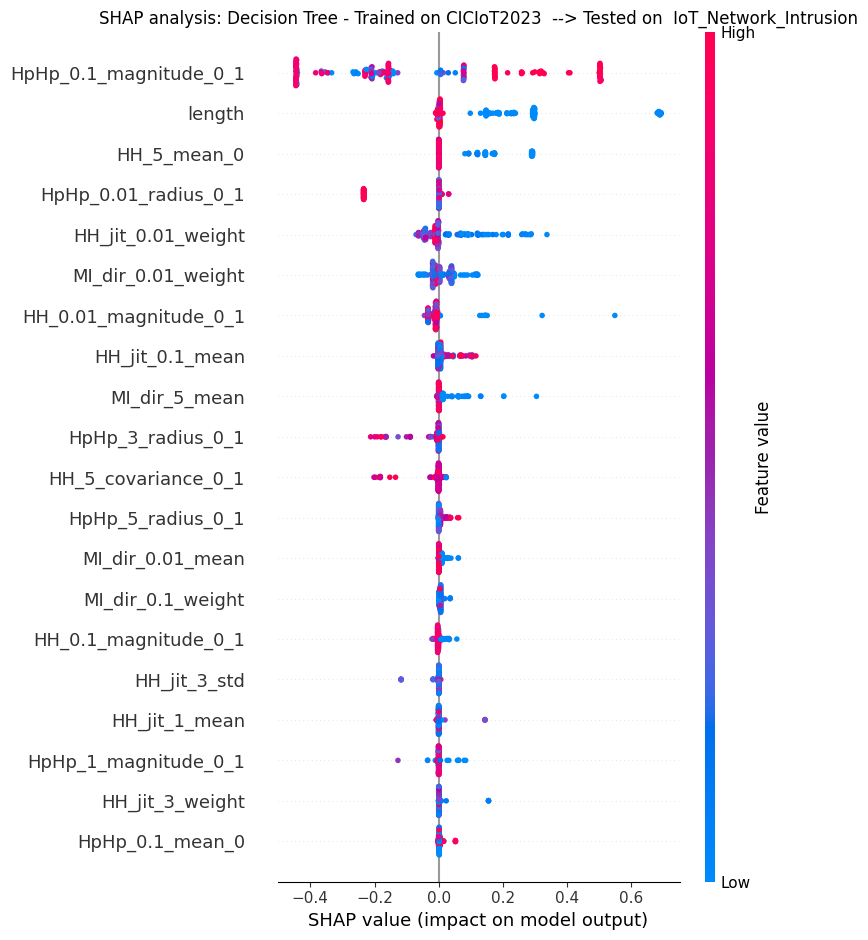


 Computing SHAP for Random Forest...


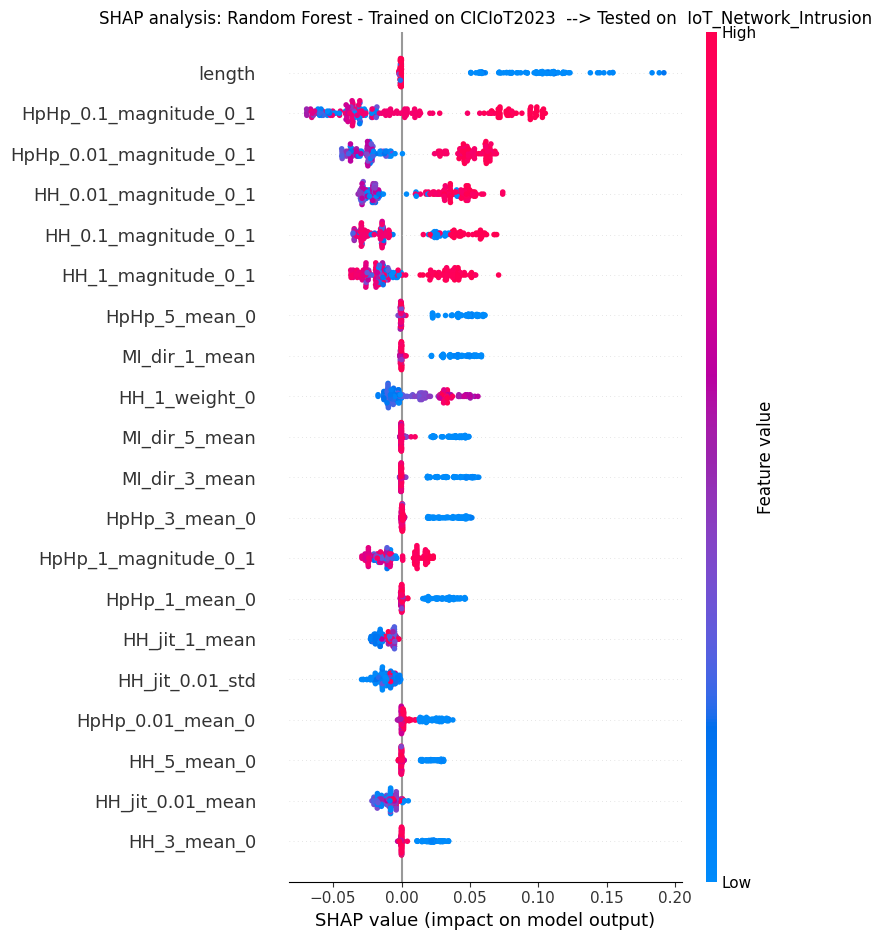


 Computing SHAP for XGBoost...


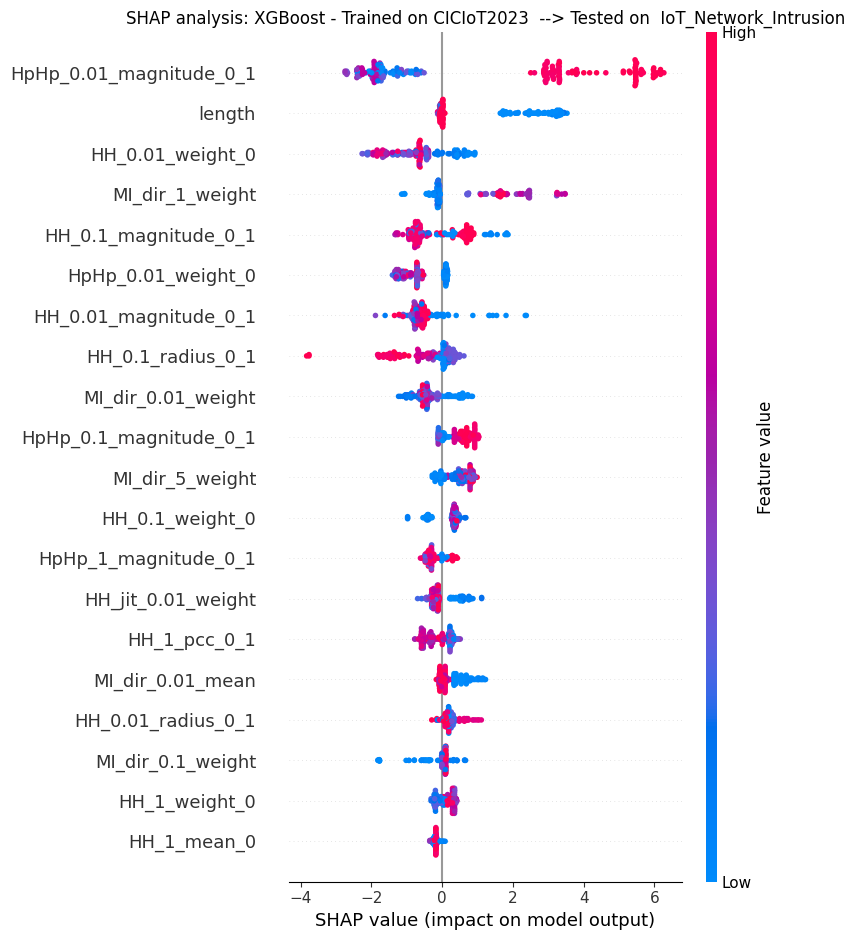

Background dataset has 32000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=32000 when initializing the masker.



 Computing SHAP values for Logistic Regression model...


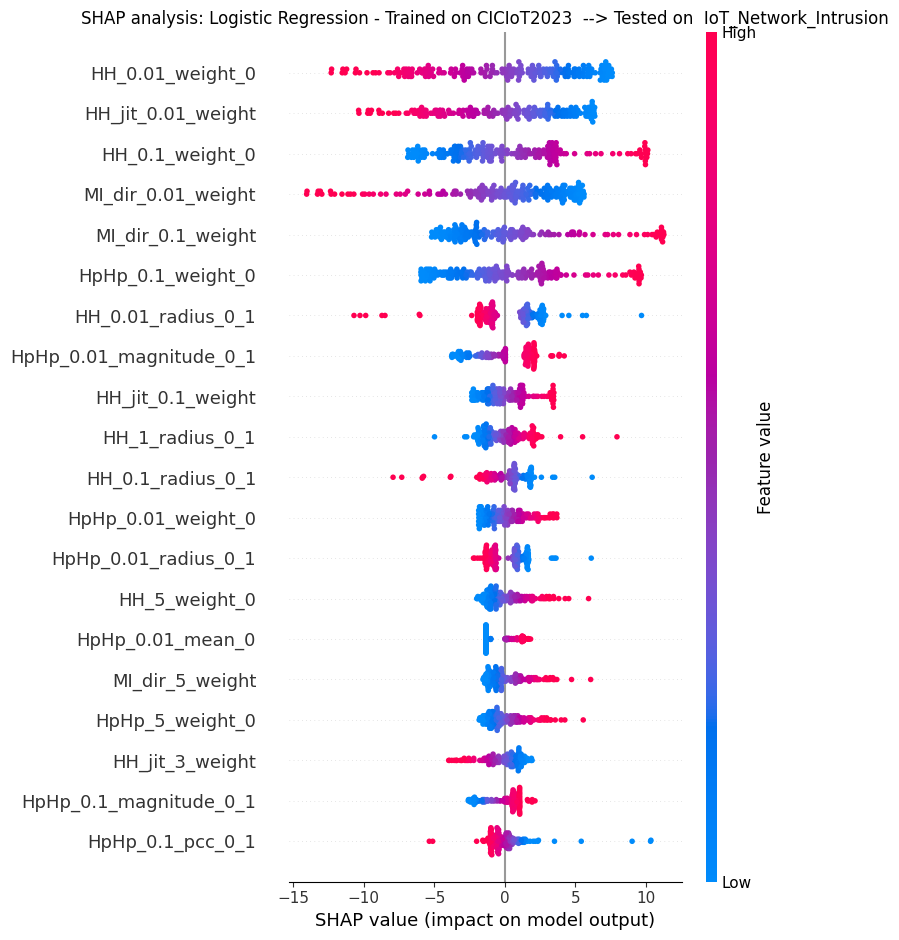


 Computing SHAP for KNN...


100%|██████████████████████████████████████████████████████████████████████████████████| 50/50 [02:39<00:00,  3.18s/it]


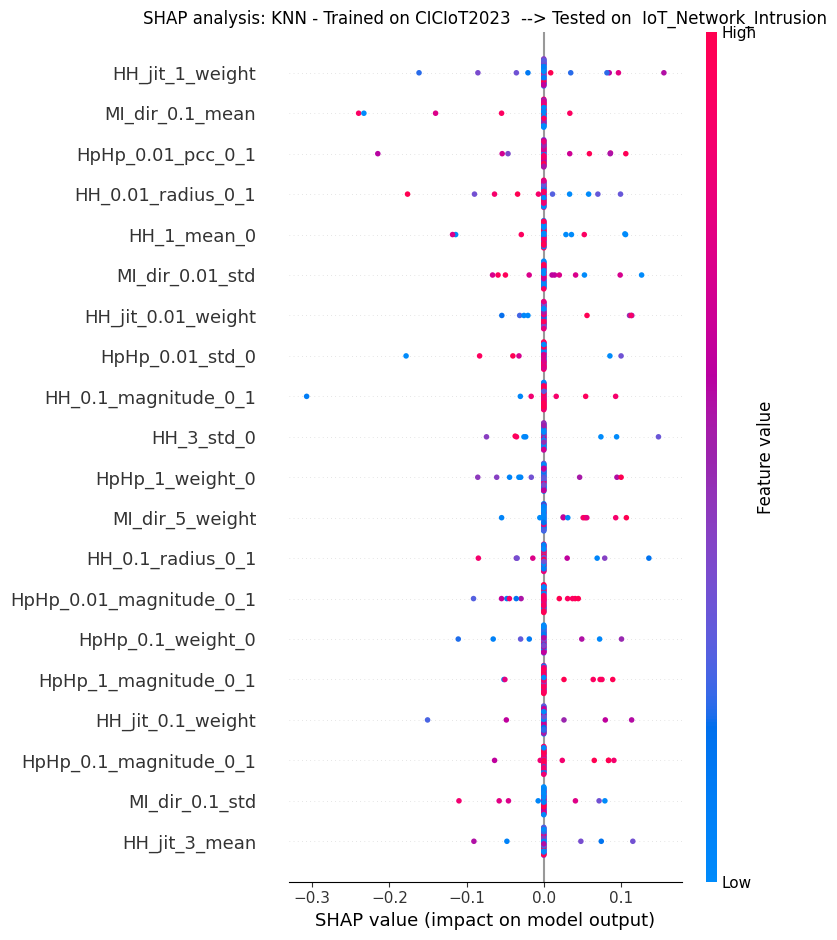


 Computing SHAP for SVM...


100%|██████████████████████████████████████████████████████████████████████████████████| 50/50 [06:53<00:00,  8.28s/it]


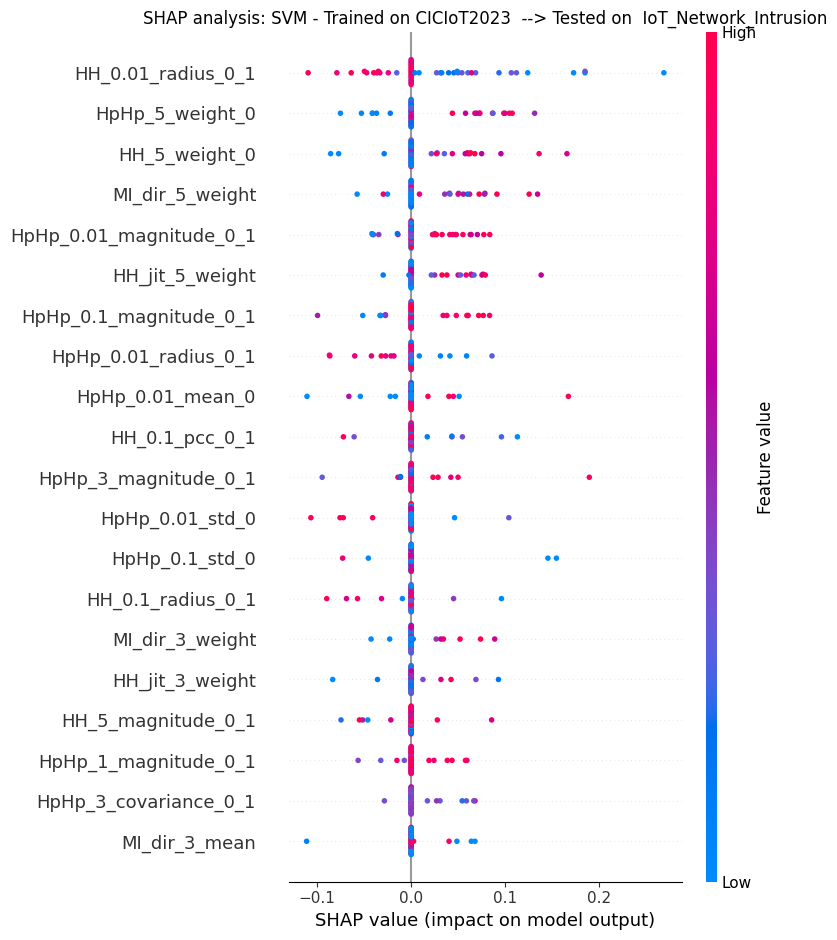

Computing SHAP values for DNN...


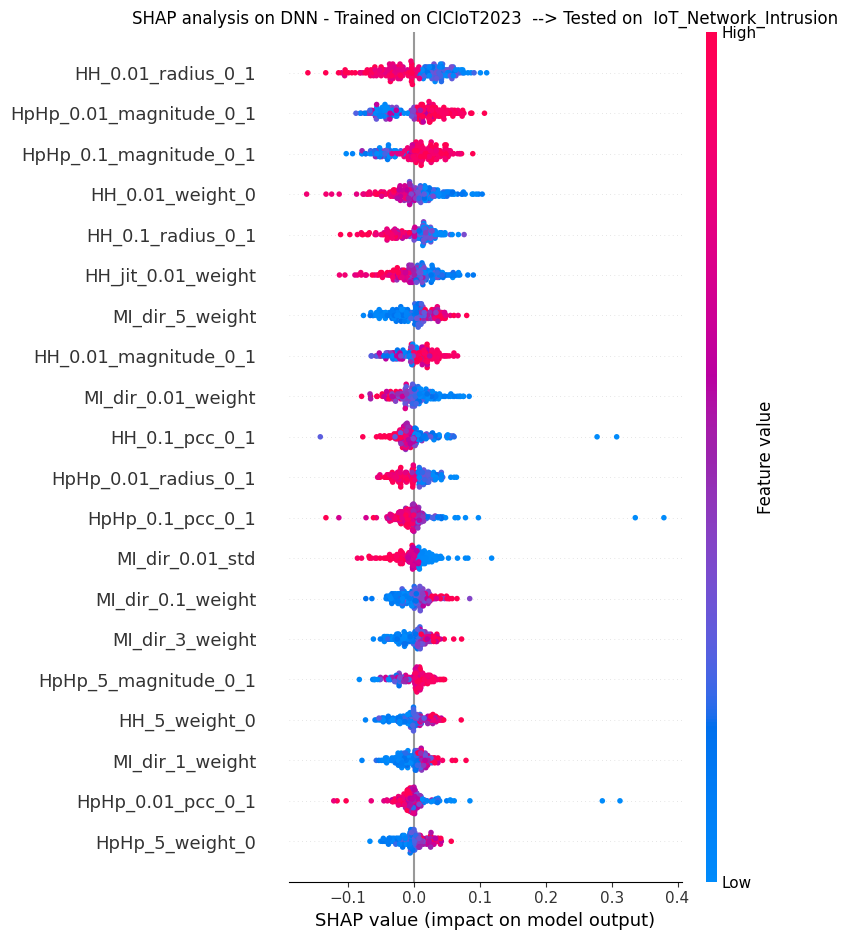


 Top 20 features across all 7 models are:

Top 10 - Decision Tree:
               Feature  Mean SHAP
HpHp_0.1_magnitude_0_1   0.261925
                length   0.148821
           HH_5_mean_0   0.088220
  HpHp_0.01_radius_0_1   0.052333
    HH_jit_0.01_weight   0.049403
    MI_dir_0.01_weight   0.028204
 HH_0.01_magnitude_0_1   0.022827
       HH_jit_0.1_mean   0.015822
         MI_dir_5_mean   0.015314
     HpHp_3_radius_0_1   0.013878

Top 10 - Random Forest:
                Feature  Mean SHAP
                 length   0.049705
 HpHp_0.1_magnitude_0_1   0.045257
HpHp_0.01_magnitude_0_1   0.037901
  HH_0.01_magnitude_0_1   0.031302
   HH_0.1_magnitude_0_1   0.028848
     HH_1_magnitude_0_1   0.024163
          HpHp_5_mean_0   0.019188
          MI_dir_1_mean   0.017900
          HH_1_weight_0   0.017229
          MI_dir_5_mean   0.016320

Top 10 - XGBoost:
                Feature  Mean SHAP
HpHp_0.01_magnitude_0_1   2.936214
                 length   1.390842
       HH_0.01_weight_0 

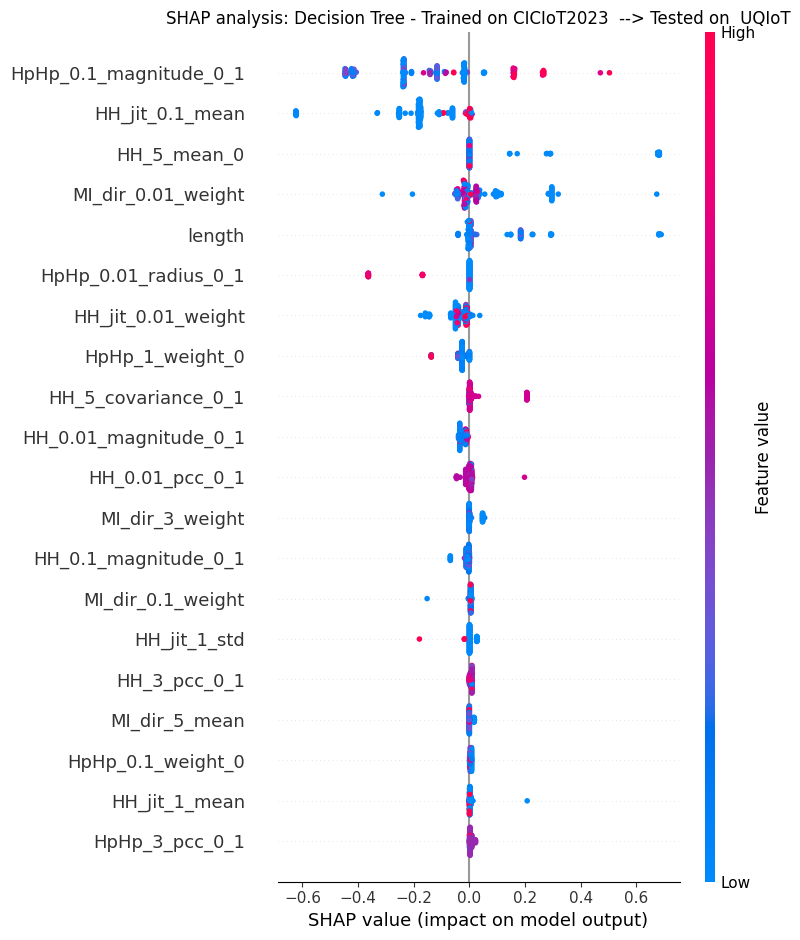


 Computing SHAP for Random Forest...


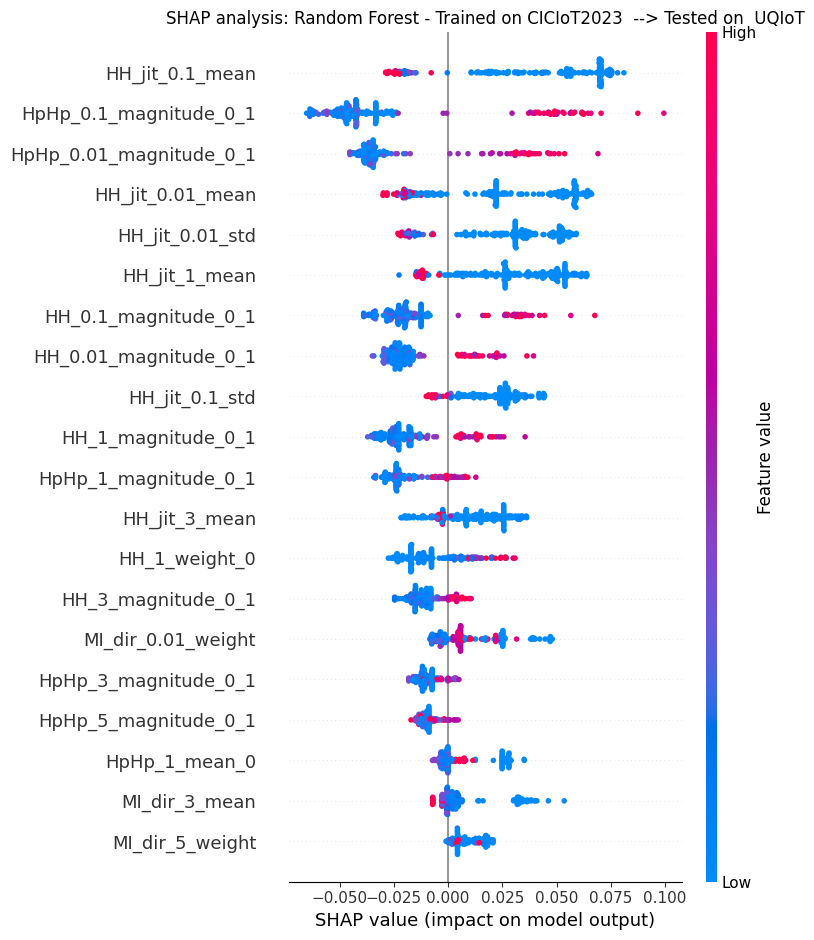


 Computing SHAP for XGBoost...


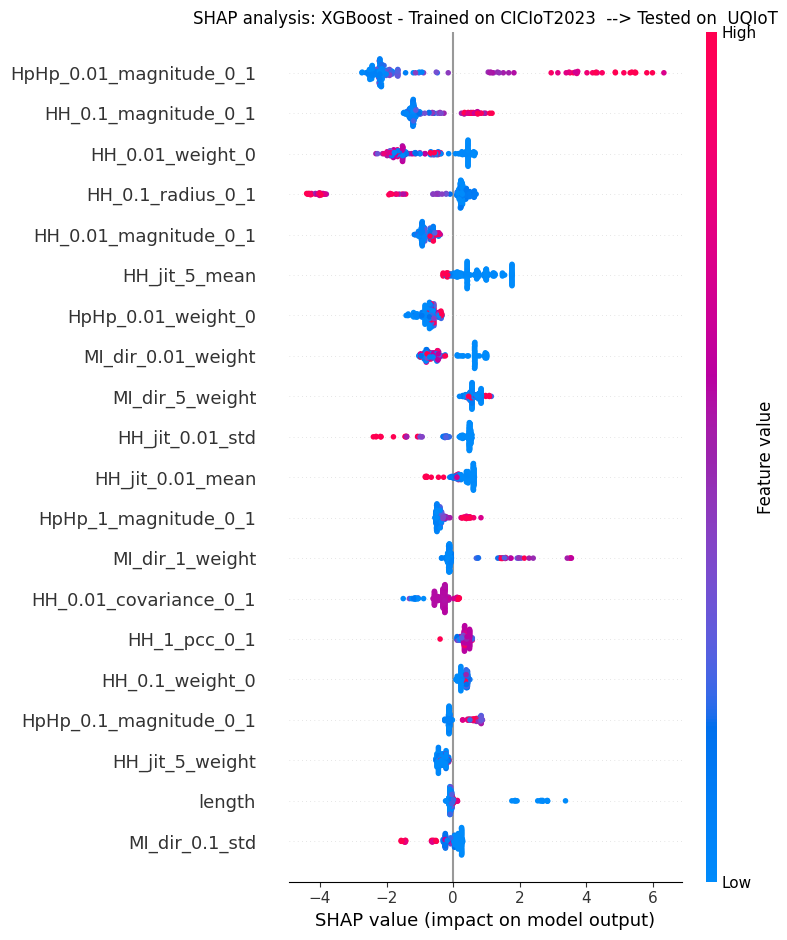

Background dataset has 32000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=32000 when initializing the masker.



 Computing SHAP values for Logistic Regression model...


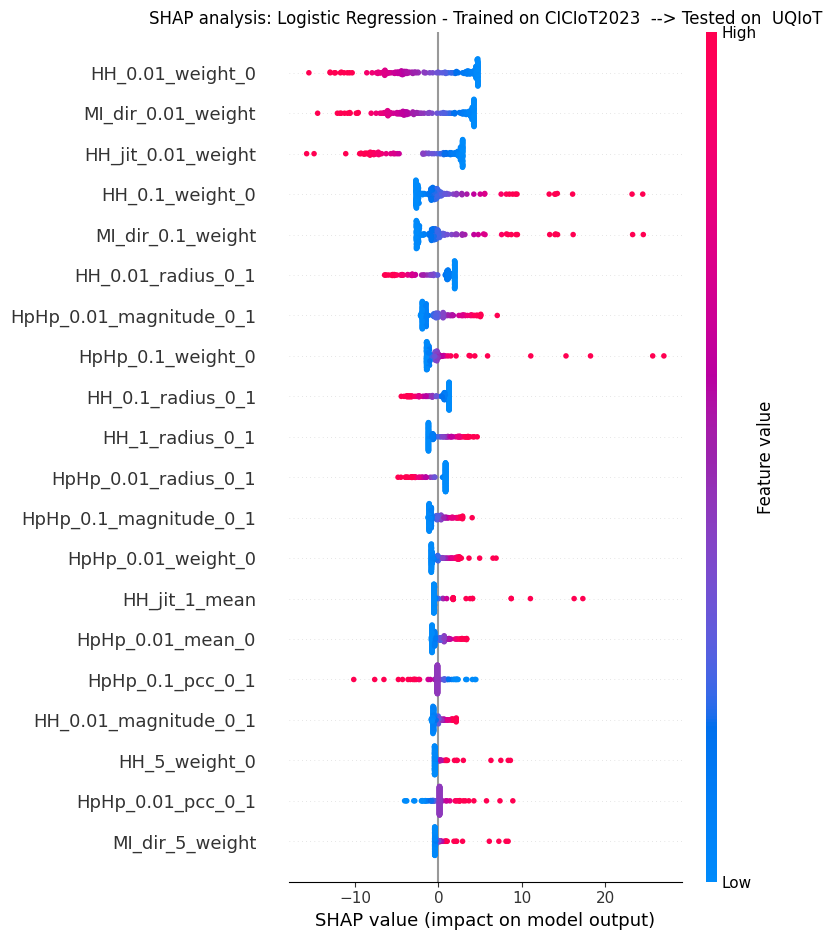


 Computing SHAP for KNN...


  6%|████▉                                                                              | 3/50 [00:17<04:26,  5.67s/it]

In [ ]:
all_cross_dataset_shap={}

for combination, (models, X_train_df, X_test_df) in trained_combinations.items():
    train_name, test_name=combination.split("->")
    print(f"\nSHAP Combination: {combination}")

    shap_values=shap_for_combination(models=models, X_train_df=X_train_df, X_test_df=X_test_df, train_name=train_name, test_name=test_name)
    all_cross_dataset_shap[combination]=shap_values

print("\nALL cross-dataset SHAP are calculated")